# Processing cell-attached spiking data for each motoneuron

In [1]:
# parent_folder_path = "/Users/haleyoro/Desktop/" # work on library computer
parent_folder_path = "/Users/Haley/Desktop/" # work on local computer

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pyabf
import os
from waveforms_helpers import *
import pickle
from cellattachedspikes import *

In [3]:
with open("sheets.pkl", "rb") as f:
    sheets = pickle.load(f)

In [4]:
sheets.keys()

dict_keys(['2012_04_25_cell1', '2012_04_25_cell3', '2012_04_27_cell1', '2012_06_22_cell3', '2012_06_25_cell3', '2012_06_29', '2012_08_01_cell1', '2012_08_01_cell3', '2012_08_07', '2012_08_31_cell1', '2012_08_31_cell2', '2012_08_31_cell3', '2012_08_31_cell4', '2012_10_04_cell2', '2012_12_03_cell1', '2012_12_04_cell1', '2012_12_04_cell2', '2012_12_05_cell1', '2012_12_05_cell3', '2012_12_05_cell4', '2012_12_06_cell1', '2012_12_06_cell2', '2012_12_06_cell3', '2012_12_06_cell4', '2012_12_06_cell5', '2012_12_06_cell6', '2013_03_20_cell1', '2013_03_21_cell1', '2013_03_21_cell2', '2013_03_21_cell3', '2013_03_21_cell4', '2013_03_21_cell5', '2013_03_22_cell1', '2013_03_22_cell2', '2013_03_22_cell3', '2013_03_22_cell4', '2013_03_22_cell5', '2013_03_22_cell6', '2012_10_04_cell1'])

In [5]:
sheets['2012_04_25_cell1']

,Trace name,ID,On time,Freq,Tags,Type,Seconds,Cell Type,Input Resistance,Motoneuron
0,2012_04_25_0004,1,1285.99,NaN,bout start; shock,Inhibitory,1.28599,vRoP,74.45,primary
1,2012_04_25_0004,2,1305.92,50.1756,<NA>,Inhibitory,1.30592,vRoP,74.45,primary
2,2012_04_25_0004,3,1340.95,28.5470,<NA>,Inhibitory,1.34095,vRoP,74.45,primary
3,2012_04_25_0004,4,1371.30,32.9489,<NA>,Inhibitory,1.37130,vRoP,74.45,primary
4,2012_04_25_0004,5,1405.23,29.4724,bout end,Inhibitory,1.40523,vRoP,74.45,primary
...,...,...,...,...,...,...,...,...,...,...
153,2012_04_25_0002,13,4726.57,39.7141,<NA>,Excitatory,4.72657,vRoP,74.45,primary
154,2012_04_25_0002,14,4755.30,34.8068,<NA>,Excitatory,4.75530,vRoP,74.45,primary
155,2012_04_25_0002,15,4780.80,39.2157,<NA>,Excitatory,4.78080,vRoP,74.45,primary
156,2012_04_25_0002,16,4808.89,35.5999,<NA>,Excitatory,4.80889,vRoP,74.45,primary


In [6]:
matches, non_matches = split_cell_attached(sheets)

# print("✅ Sheets WITH Cell-attached traces:")
# for sheet, rows in matches.items():
#     print(f"  - {sheet} ({len(rows)} rows)")

print("\n❌ Sheets WITHOUT Cell-attached traces:")
for sheet in non_matches:
    print(f"  - {sheet}")


❌ Sheets WITHOUT Cell-attached traces:
  - 2012_04_25_cell1
  - 2012_04_25_cell3
  - 2012_04_27_cell1
  - 2012_06_22_cell3
  - 2012_06_25_cell3
  - 2012_06_29
  - 2013_03_22_cell3


In [7]:
matches, non_matches = split_cell_attached_spiking(sheets)

# print("✅ Sheets WITH Cell-attached traces:")
# for sheet, rows in matches.items():
#     print(f"  - {sheet} ({len(rows)} rows)")

print("\n❌ Sheets WITHOUT Cell-attached spiking traces:")
for sheet in non_matches:
    print(f"  - {sheet}")


❌ Sheets WITHOUT Cell-attached spiking traces:
  - 2012_04_25_cell1
  - 2012_04_25_cell3
  - 2012_04_27_cell1
  - 2012_06_22_cell3
  - 2012_06_25_cell3
  - 2012_06_29
  - 2013_03_22_cell3


In [8]:
cell_attached_dict = filter_cell_attached(sheets)

print("New dictionary contains only Cell-attached / Cell-attached (spiking) rows from:")
for sheet, df in cell_attached_dict.items():
    print(f"  - {sheet}: {len(df)} rows")

New dictionary contains only Cell-attached / Cell-attached (spiking) rows from:
  - 2012_08_01_cell1: 170 rows
  - 2012_08_01_cell3: 224 rows
  - 2012_08_07: 141 rows
  - 2012_08_31_cell1: 321 rows
  - 2012_08_31_cell2: 911 rows
  - 2012_08_31_cell3: 185 rows
  - 2012_08_31_cell4: 134 rows
  - 2012_10_04_cell2: 340 rows
  - 2012_12_03_cell1: 684 rows
  - 2012_12_04_cell1: 277 rows
  - 2012_12_04_cell2: 211 rows
  - 2012_12_05_cell1: 288 rows
  - 2012_12_05_cell3: 701 rows
  - 2012_12_05_cell4: 1229 rows
  - 2012_12_06_cell1: 167 rows
  - 2012_12_06_cell2: 404 rows
  - 2012_12_06_cell3: 421 rows
  - 2012_12_06_cell4: 800 rows
  - 2012_12_06_cell5: 397 rows
  - 2012_12_06_cell6: 258 rows
  - 2013_03_20_cell1: 304 rows
  - 2013_03_21_cell1: 419 rows
  - 2013_03_21_cell2: 739 rows
  - 2013_03_21_cell3: 279 rows
  - 2013_03_21_cell4: 1218 rows
  - 2013_03_21_cell5: 379 rows
  - 2013_03_22_cell1: 498 rows
  - 2013_03_22_cell2: 639 rows
  - 2013_03_22_cell4: 911 rows
  - 2013_03_22_cell5: 312

In [9]:
with open("cell_attached_sheets.pkl", "wb") as f:
    pickle.dump(cell_attached_dict, f)

In [10]:
cell_attached_dict.keys()
cell_attached_dict['2012_08_01_cell1']

,Trace name,ID,On time,Freq,Tags,Type,Seconds,Cell Type,Input Resistance,Motoneuron
442,2012_08_01_0002,1,2181.54,NaN,bout start; shock,Cell-attached,2.18154,vSMN,287.0,Low Rin Secondary
443,2012_08_01_0002,2,2212.18,32.6371,<NA>,Cell-attached,2.21218,vSMN,287.0,Low Rin Secondary
444,2012_08_01_0002,3,2238.12,38.5505,<NA>,Cell-attached,2.23812,vSMN,287.0,Low Rin Secondary
445,2012_08_01_0002,4,2277.70,25.2653,<NA>,Cell-attached,2.27770,vSMN,287.0,Low Rin Secondary
446,2012_08_01_0002,5,2316.77,25.5951,<NA>,Cell-attached,2.31677,vSMN,287.0,Low Rin Secondary
...,...,...,...,...,...,...,...,...,...,...
607,2012_08_01_0003,21,6448.56,16.2575,<NA>,Cell-attached (spiking),6.44856,vSMN,287.0,Low Rin Secondary
608,2012_08_01_0003,22,8173.00,0.5799,<NA>,Cell-attached (spiking),8.17300,vSMN,287.0,Low Rin Secondary
609,2012_08_01_0003,23,8209.73,27.2257,<NA>,Cell-attached (spiking),8.20973,vSMN,287.0,Low Rin Secondary
610,2012_08_01_0003,24,8381.96,5.8062,<NA>,Cell-attached (spiking),8.38196,vSMN,287.0,Low Rin Secondary


making sure frequency is correctly calculated

In [11]:
updated = recalc_freq_cell_attached(cell_attached_dict['2012_08_01_cell1'])
print(updated[["ID", "Seconds", "Freq"]])

     ID  Seconds       Freq
442   1  2.18154        NaN
443   2  2.21218  32.637076
444   3  2.23812  38.550501
445   4  2.27770  25.265285
446   5  2.31677  25.595086
..   ..      ...        ...
607  21  6.44856  16.257500
608  22  8.17300   0.579900
609  23  8.20973  27.225700
610  24  8.38196   5.806200
611  25  8.76629   2.601900

[170 rows x 3 columns]


In [12]:
spikes = assign_spike_frequencies_for_dict(cell_attached_dict)
spikes

{'2012_08_01_cell1':          Trace name  trace_time  spike_frequency  burst_index
 0   2012_08_01_0002     2.24773        38.550501            3
 1   2012_08_01_0002     2.28153        25.265285            4
 2   2012_08_01_0002     2.31920        25.595086            5
 3   2012_08_01_0002     2.36224        20.746888            6
 4   2012_08_01_0002     2.40853        24.108004            7
 5   2012_08_01_0002     2.45127        22.872827            8
 6   2012_08_01_0002     2.54308        19.127774           10
 7   2012_08_01_0002     2.67411        20.738283           13
 8   2012_08_01_0002     2.71757        24.301337           14
 9   2012_08_01_0002     2.75876        25.169897           15
 10  2012_08_01_0002     2.79726        25.284450           16
 11  2012_08_01_0002     2.83865        25.406504           17
 12  2012_08_01_0002     2.97572        24.491795           20
 13  2012_08_01_0002     3.67887        27.173913           28
 14  2012_08_01_0002     3.85500   

In [13]:
all_spikes = combine_spike_dict(spikes)
print(all_spikes.head())

        Trace name  trace_time  spike_frequency  burst_index              cell
0  2012_08_01_0002     2.24773        38.550501            3  2012_08_01_cell1
1  2012_08_01_0002     2.28153        25.265285            4  2012_08_01_cell1
2  2012_08_01_0002     2.31920        25.595086            5  2012_08_01_cell1
3  2012_08_01_0002     2.36224        20.746888            6  2012_08_01_cell1
4  2012_08_01_0002     2.40853        24.108004            7  2012_08_01_cell1


In [14]:
cell_types_df = pd.read_csv(parent_folder_path+"murray-neuroscience-lab/Excel processor/List of cells.csv")
cell_types_df = cell_types_df.dropna(how='all')
cell_types_df = cell_types_df.iloc[:,:4]
cell_types_df.reset_index(drop=True,inplace=True)
cell_types_df

,Cell,Cell Type,Input Resistance,Motoneuron
0,2013_03_21_cell5,CaP,33.00,primary
1,2013_03_22_cell6,vRoP,42.00,primary
2,2013_03_22_cell2,CaP,43.64,primary
3,2012_08_31_cell2,vRoP,44.77,primary
4,2012_08_31_cell1,MiP,45.33,primary
5,2012_08_31_cell3,MiP,46.67,primary
6,2013_03_21_cell4,MiP,47.15,primary
7,2012_08_01_cell3,MiP,49.99,primary
8,2013_03_22_cell1,CaP,51.00,primary
9,2013_03_20_cell1,MiP,51.10,primary


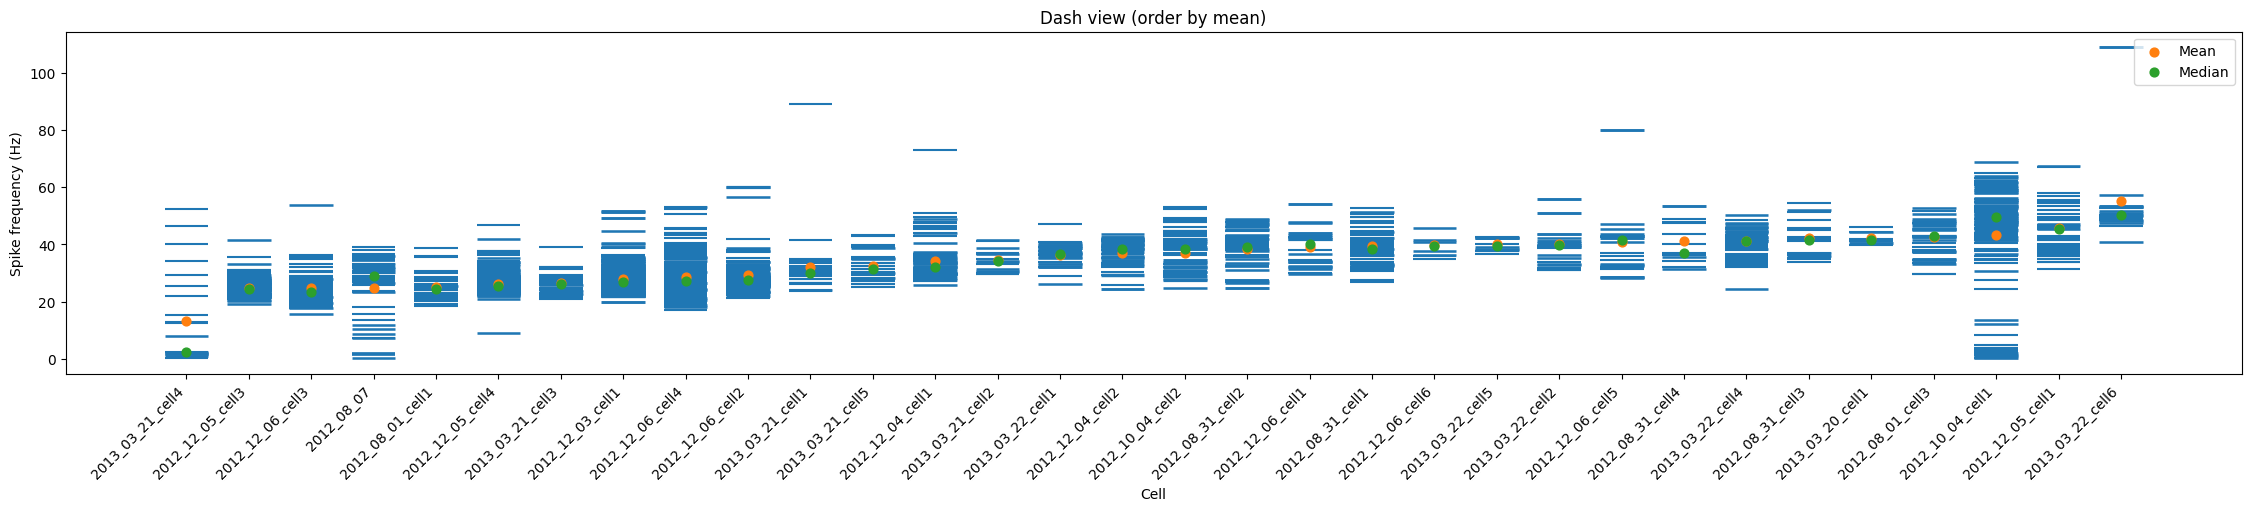

In [15]:
plot_spike_dashes(all_spikes, order_by="mean")

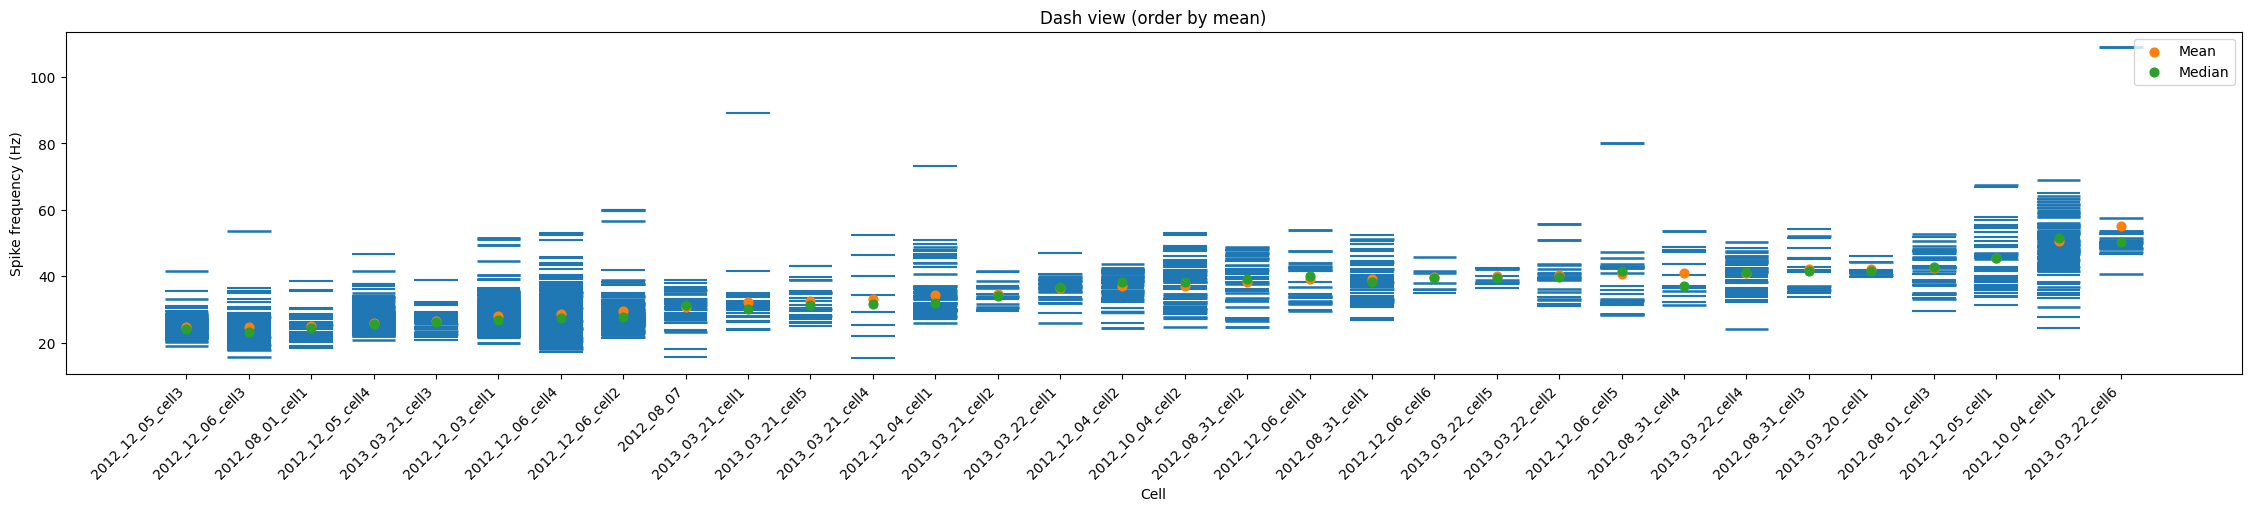

In [58]:
all_spikes_clean = clean_spikes_dataframe(all_spikes, min_freq=15)

plot_spike_dashes(all_spikes_clean, order_by="mean")

In [23]:

def summarize_spike_stats(
    all_spikes: pd.DataFrame,
    cell_col: str = "cell",
    freq_col: str = "spike_frequency",
    dropna: bool = True,
    round_decimals: int | None = None,
) -> pd.DataFrame:
    """
    Summarize spike frequencies per cell.

    Parameters
    ----------
    all_spikes : DataFrame with at least [cell_col, freq_col]
    cell_col   : column name for cell IDs (default 'cell')
    freq_col   : column name for spike frequency (Hz) (default 'spike_frequency')
    dropna     : if True, drop rows with NaN freq before aggregating
    round_decimals : optional int to round numeric outputs

    Returns
    -------
    DataFrame with columns:
      ['cell', 'mean_spike_frequency', 'median_spike_frequency',
       'min_spike_frequency', 'max_spike_frequency', 'total_spikes']
    """
    required = {cell_col, freq_col}
    missing = required - set(all_spikes.columns)
    if missing:
        raise ValueError(f"Input DataFrame missing required columns: {missing}")

    df = all_spikes[[cell_col, freq_col]].copy()
    # ensure numeric freq; coerce bad strings to NaN
    df[freq_col] = pd.to_numeric(df[freq_col], errors="coerce")
    if dropna:
        df = df.dropna(subset=[freq_col])

    out = (
        df.groupby(cell_col)[freq_col]
          .agg(
              mean_spike_frequency="mean",
              median_spike_frequency="median",
              min_spike_frequency="min",
              max_spike_frequency="max",
              total_spikes="count",   # counts non-NaN
          )
          .reset_index()
          .rename(columns={cell_col: "cell"})
    )

    if round_decimals is not None:
        num_cols = ["mean_spike_frequency", "median_spike_frequency",
                    "min_spike_frequency", "max_spike_frequency"]
        out[num_cols] = out[num_cols].round(round_decimals)

    return out

stats = summarize_spike_stats(all_spikes, round_decimals=2)
print(stats.head())
# assuming you already made: stats = summarize_spike_stats(all_spikes, round_decimals=2)

import os
out_path = os.path.join(parent_folder_path, "spike_stats.csv")  # or any folder you want
stats.to_csv(out_path, index=False)  # no extra index column
print(f"Saved: {out_path}")



               cell  mean_spike_frequency  median_spike_frequency  \
0  2012_08_01_cell1                 24.97                   24.52   
1  2012_08_01_cell3                 42.55                   42.84   
2        2012_08_07                 24.88                   28.92   
3  2012_08_31_cell1                 39.28                   38.40   
4  2012_08_31_cell2                 38.21                   39.15   

   min_spike_frequency  max_spike_frequency  total_spikes  
0                18.47                38.55            41  
1                29.46                52.69            65  
2                 0.38                38.93            81  
3                26.93                52.55            64  
4                24.64                48.71            69  
Saved: /Users/Haley/Desktop/spike_stats.csv


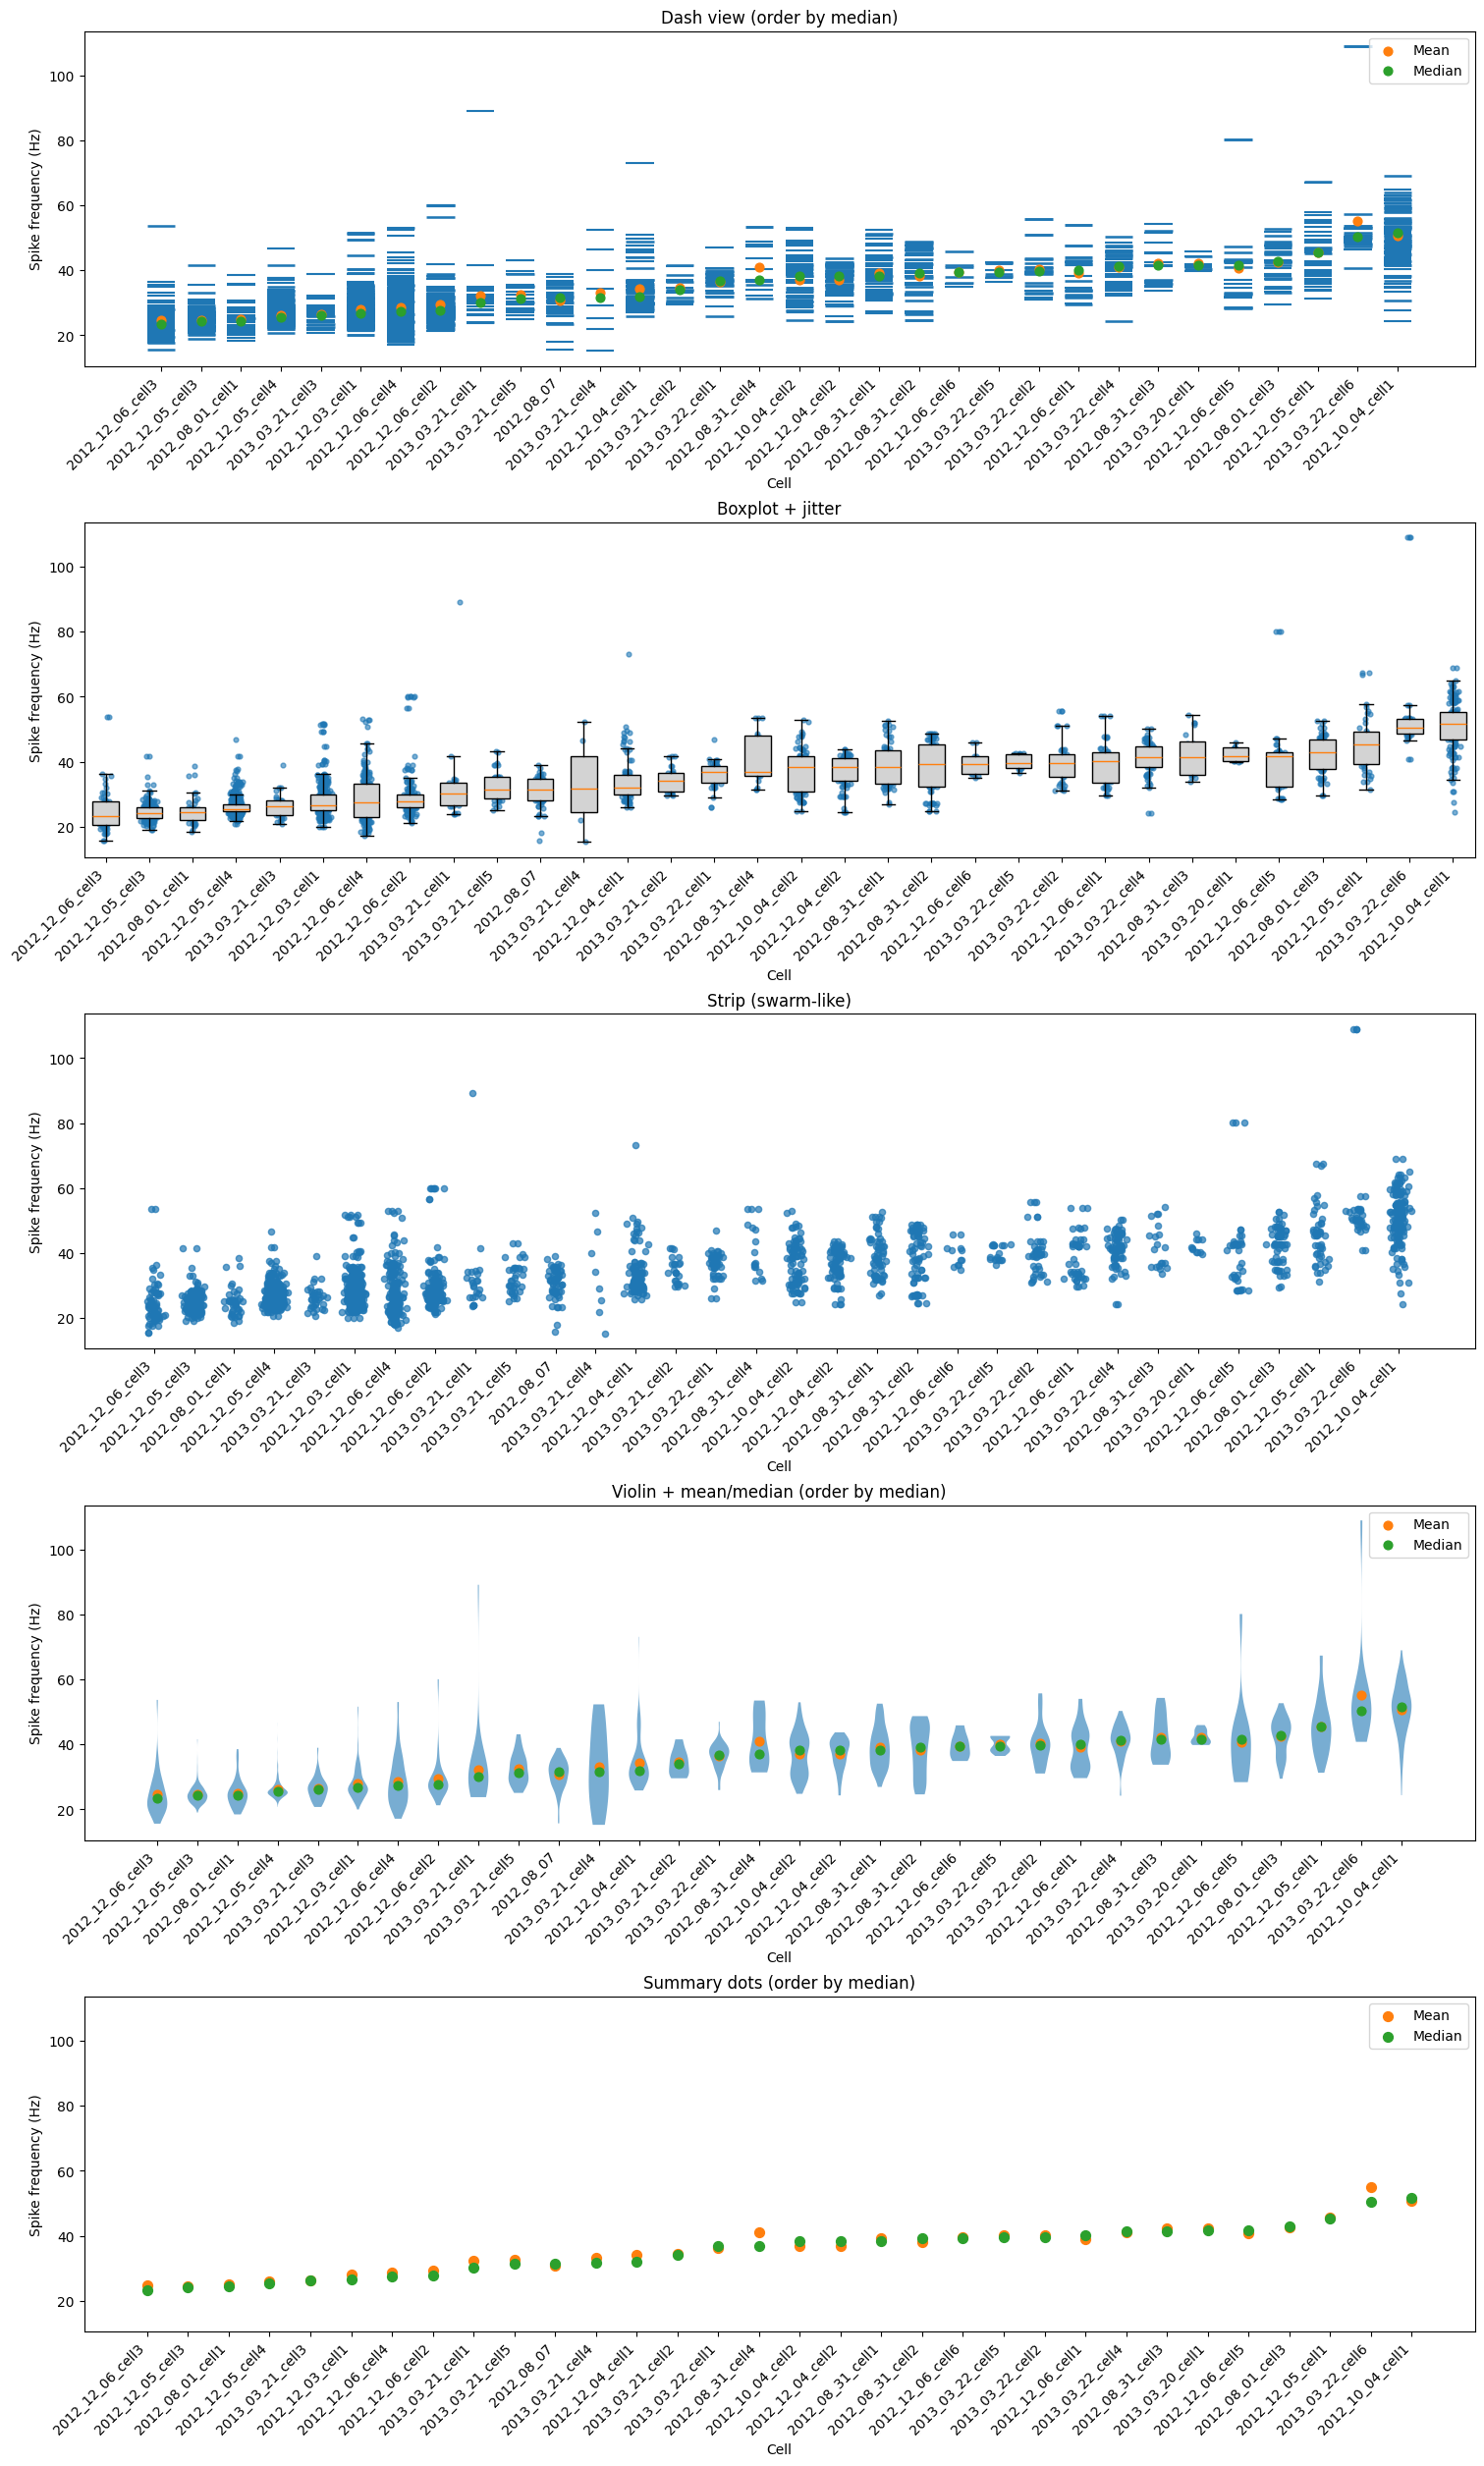

In [25]:
# Stacked 1×5 grid, order by median
plot_all_views_grid(all_spikes_clean, order_by="median")


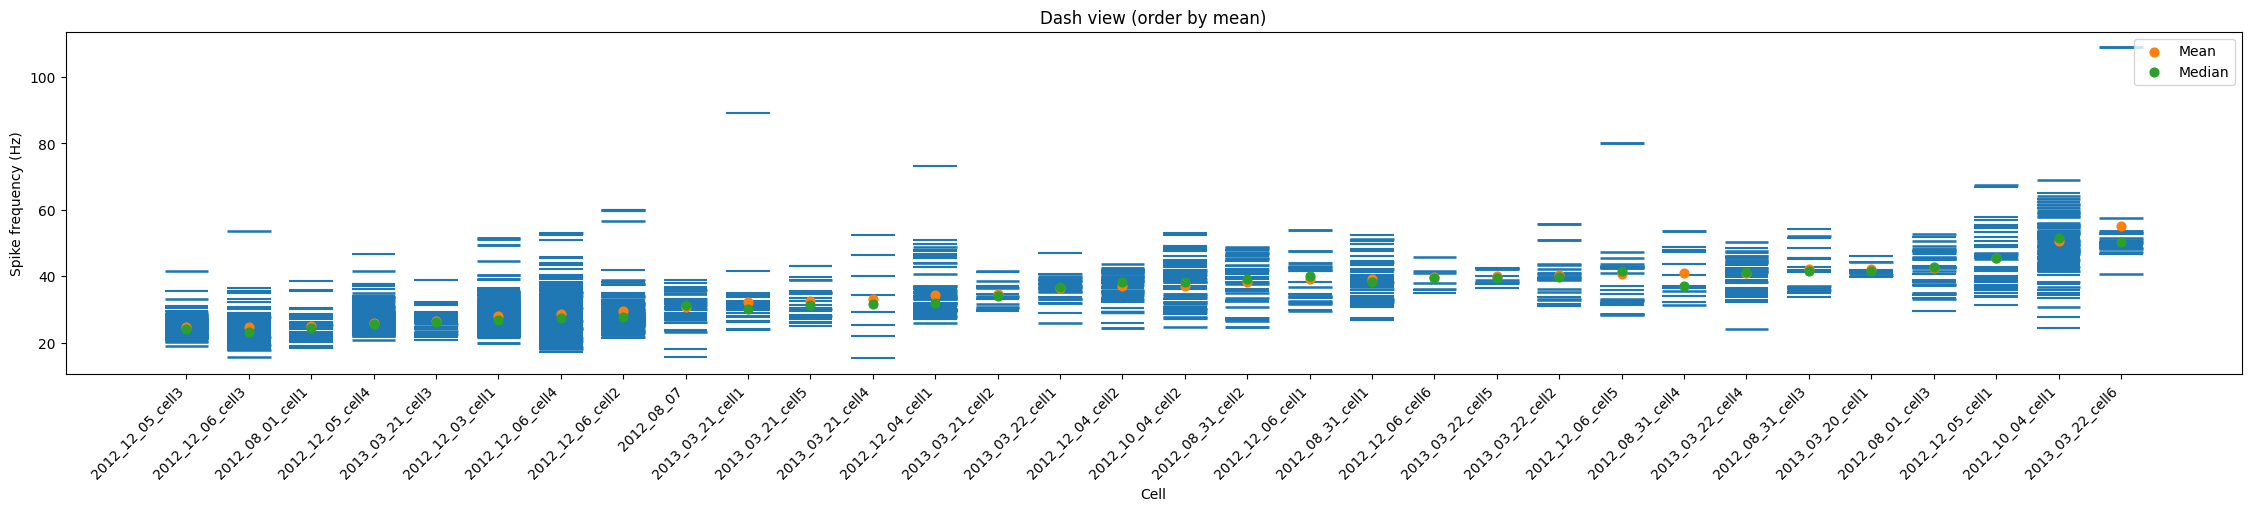

/Users/Haley/Desktop/murray-neuroscience-lab/Cleaned, updated files from Spring/cellattachedspikes.py:585: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


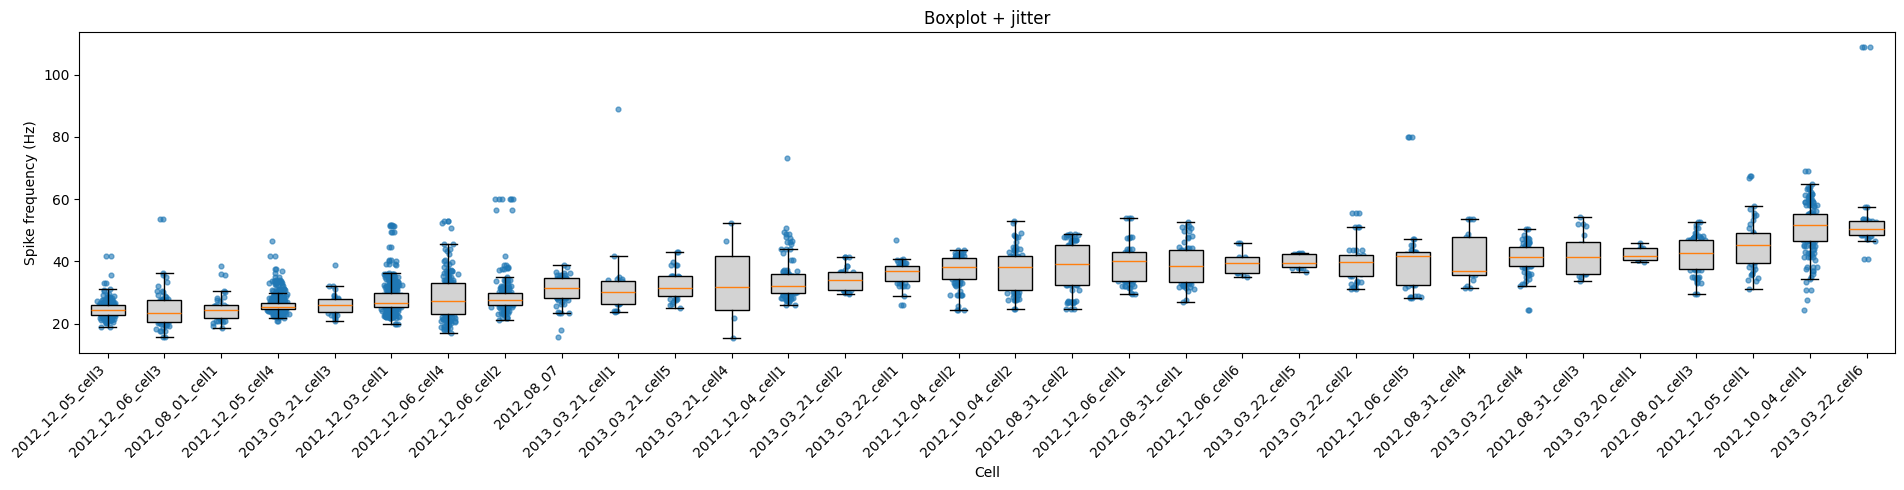

/Users/Haley/Desktop/murray-neuroscience-lab/Cleaned, updated files from Spring/cellattachedspikes.py:612: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


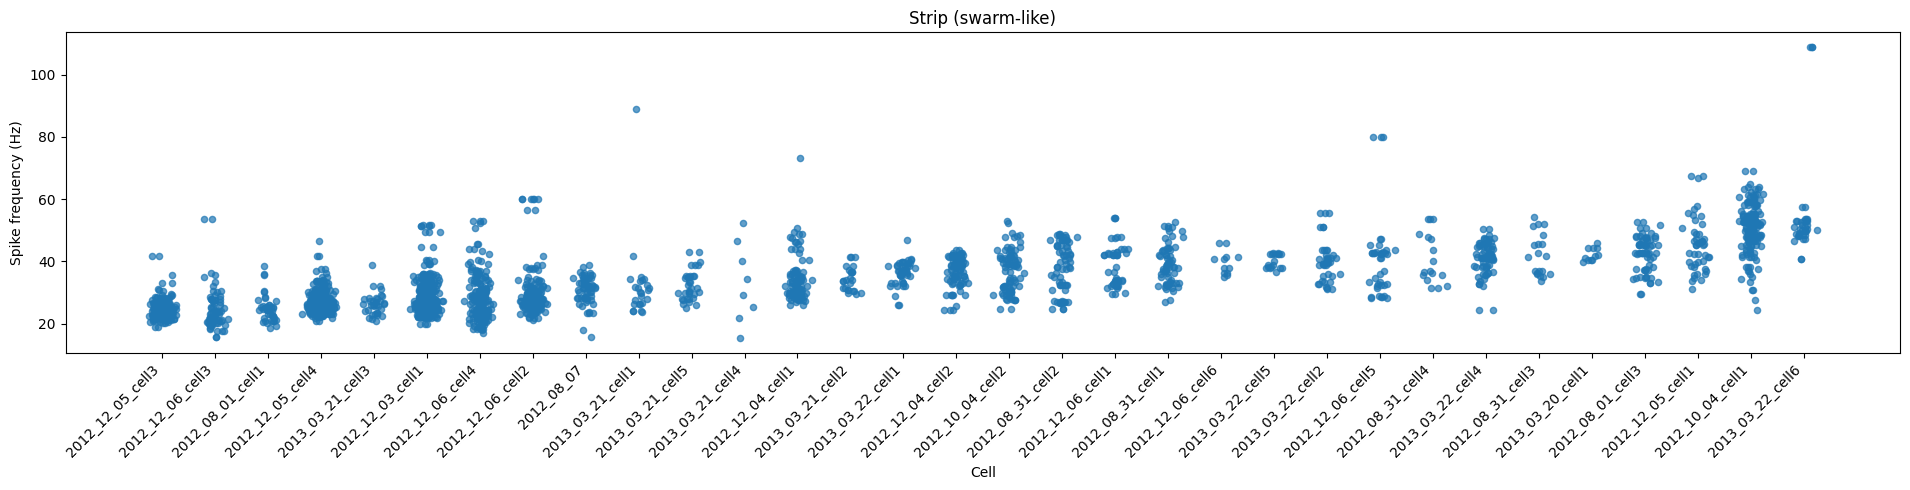

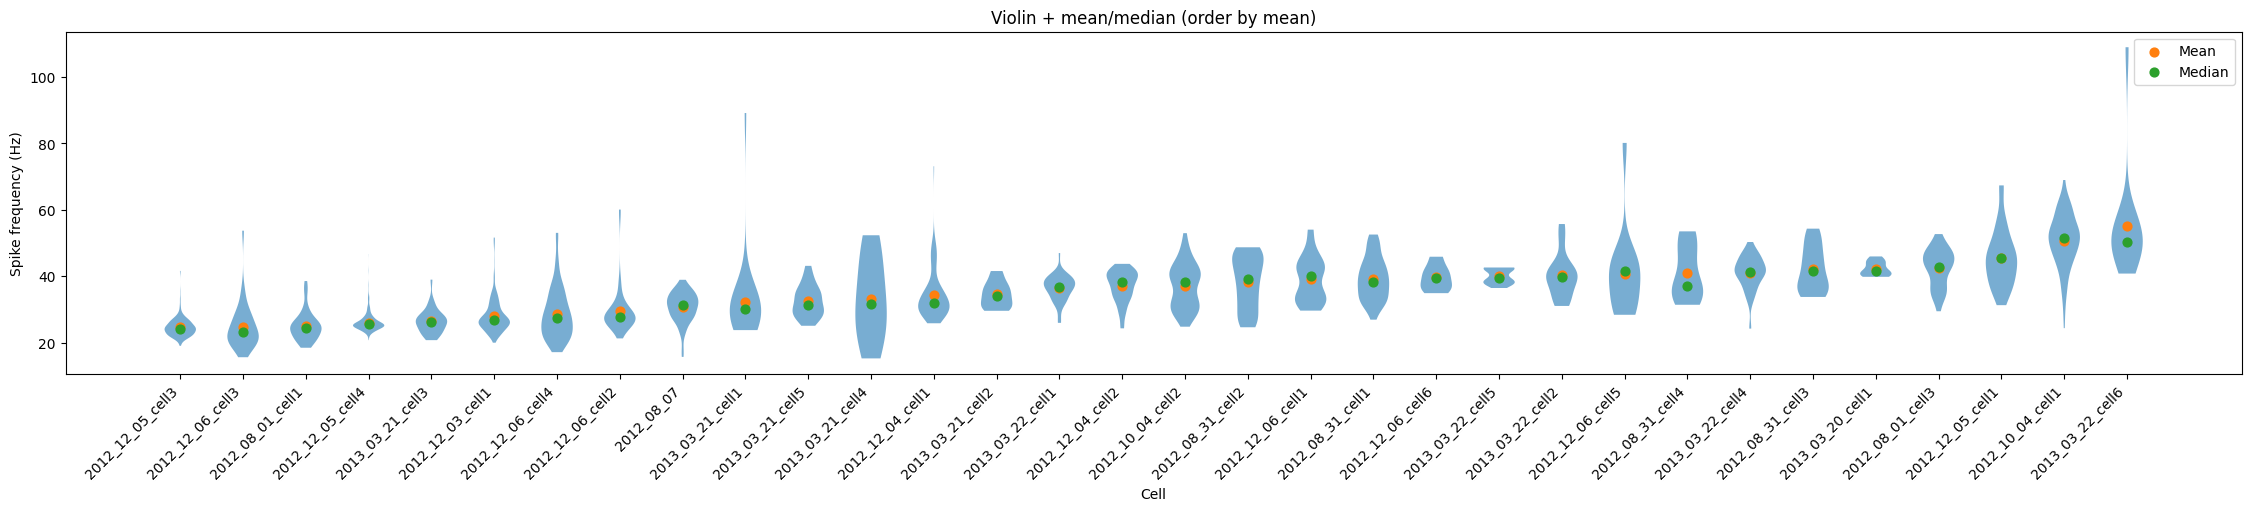

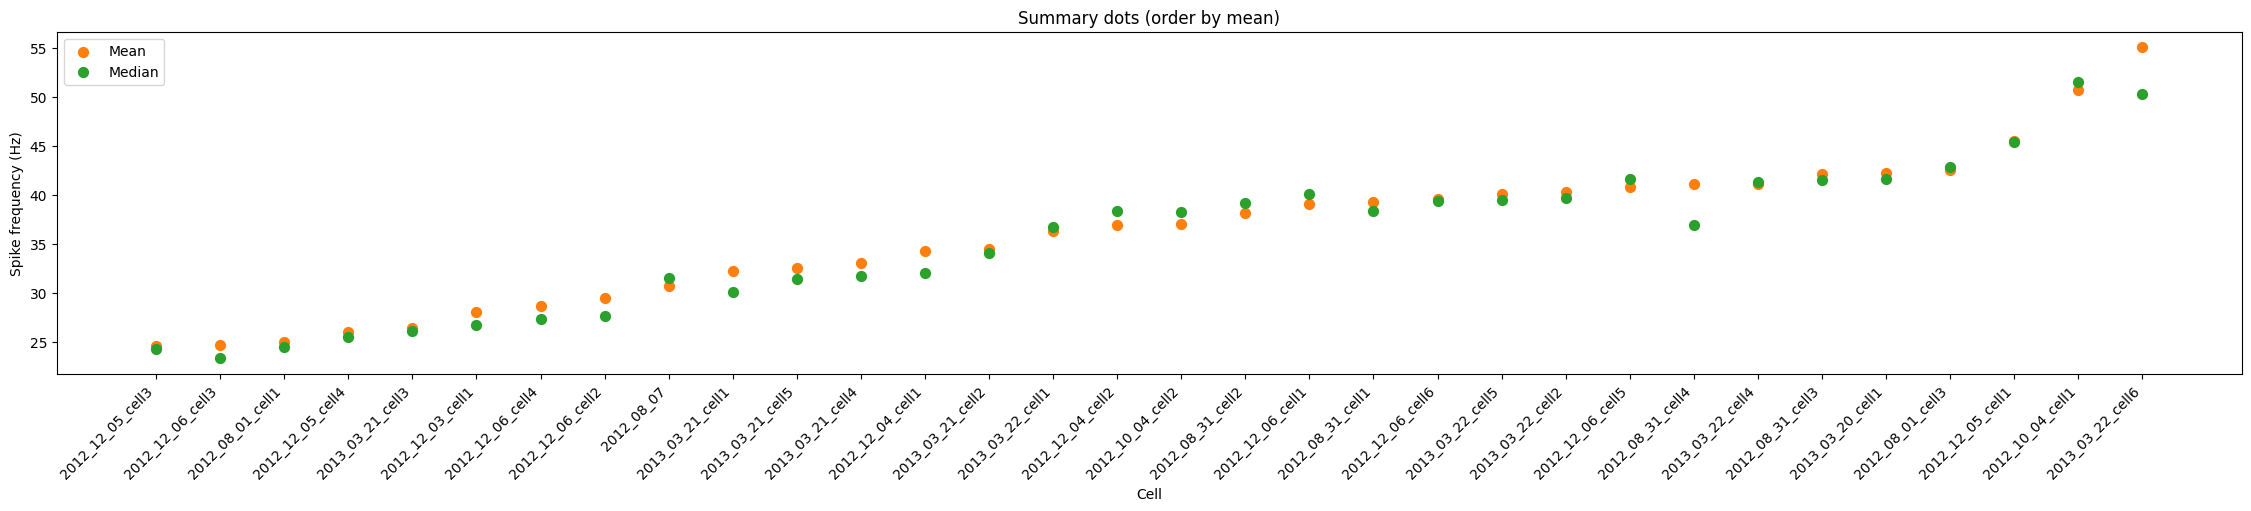

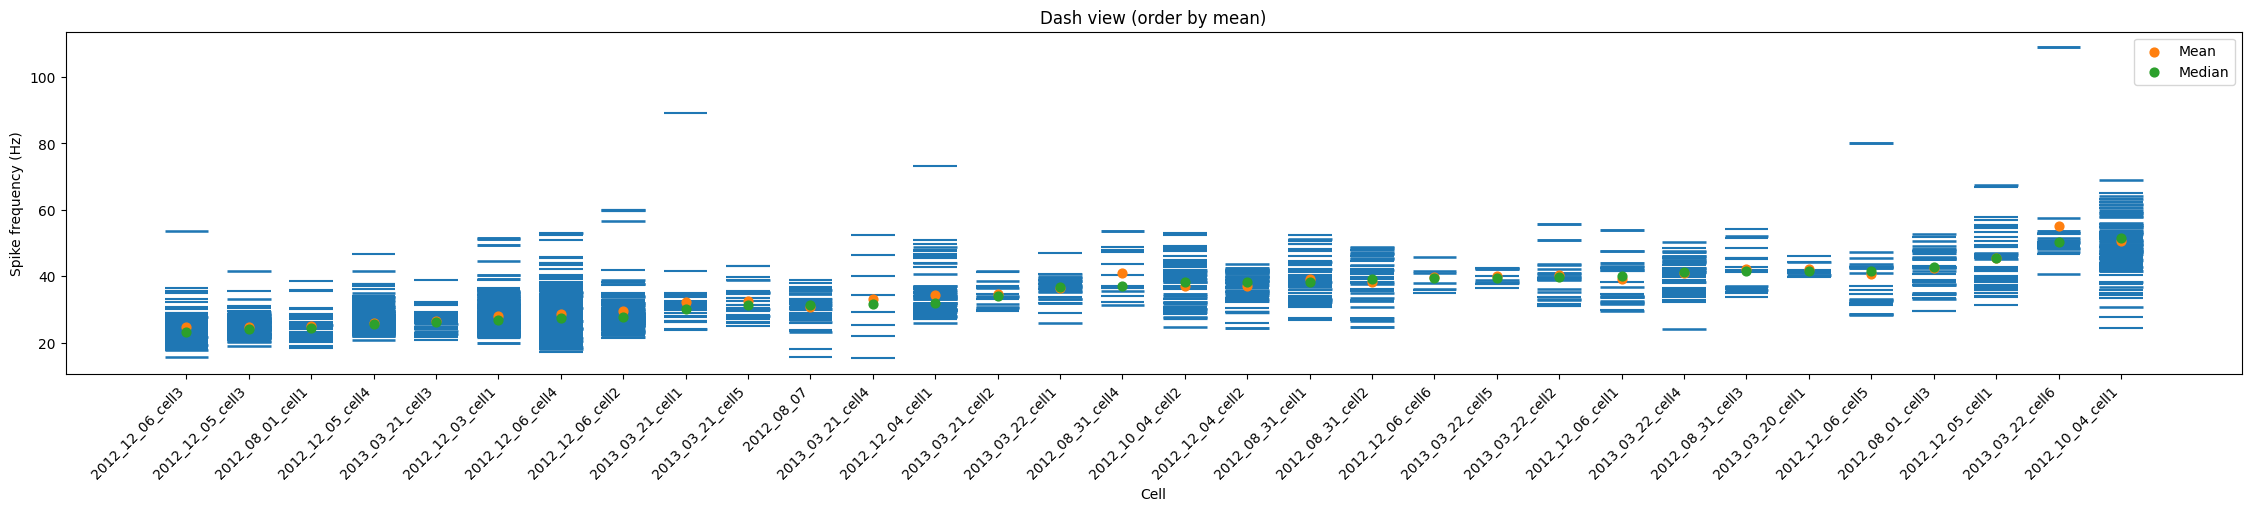

/Users/Haley/Desktop/murray-neuroscience-lab/Cleaned, updated files from Spring/cellattachedspikes.py:585: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


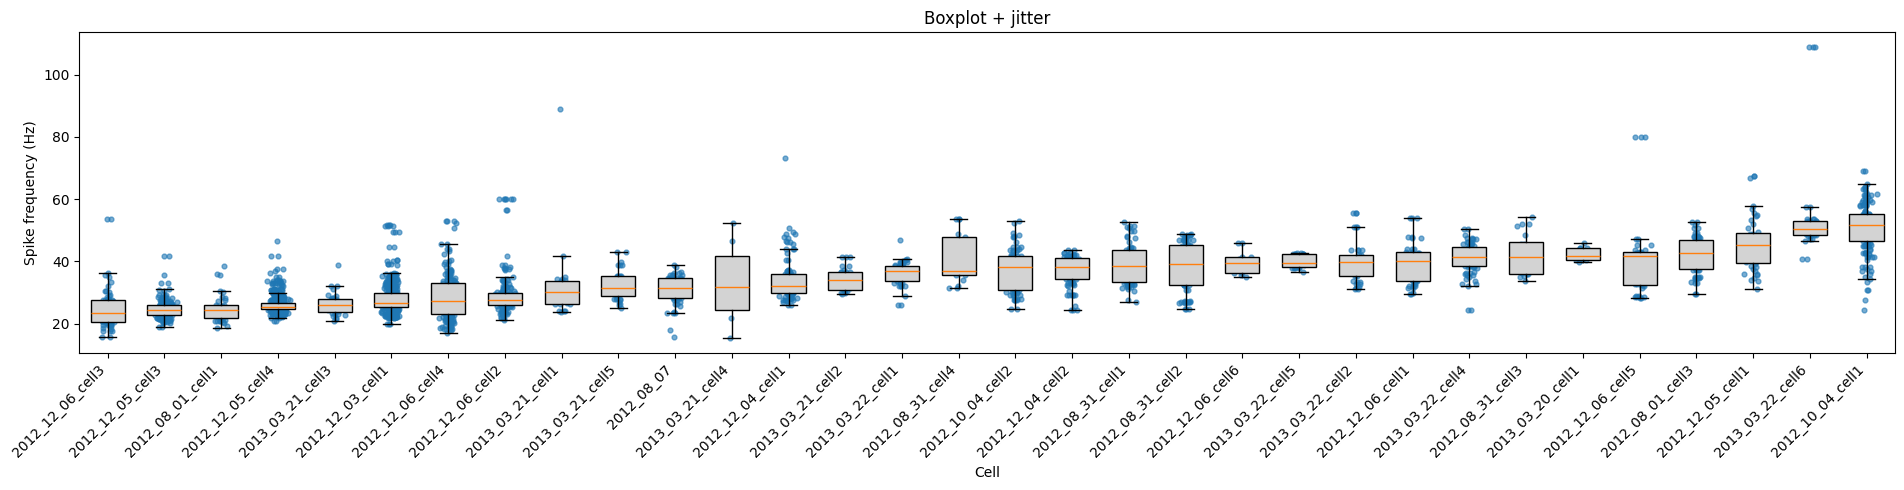

/Users/Haley/Desktop/murray-neuroscience-lab/Cleaned, updated files from Spring/cellattachedspikes.py:612: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


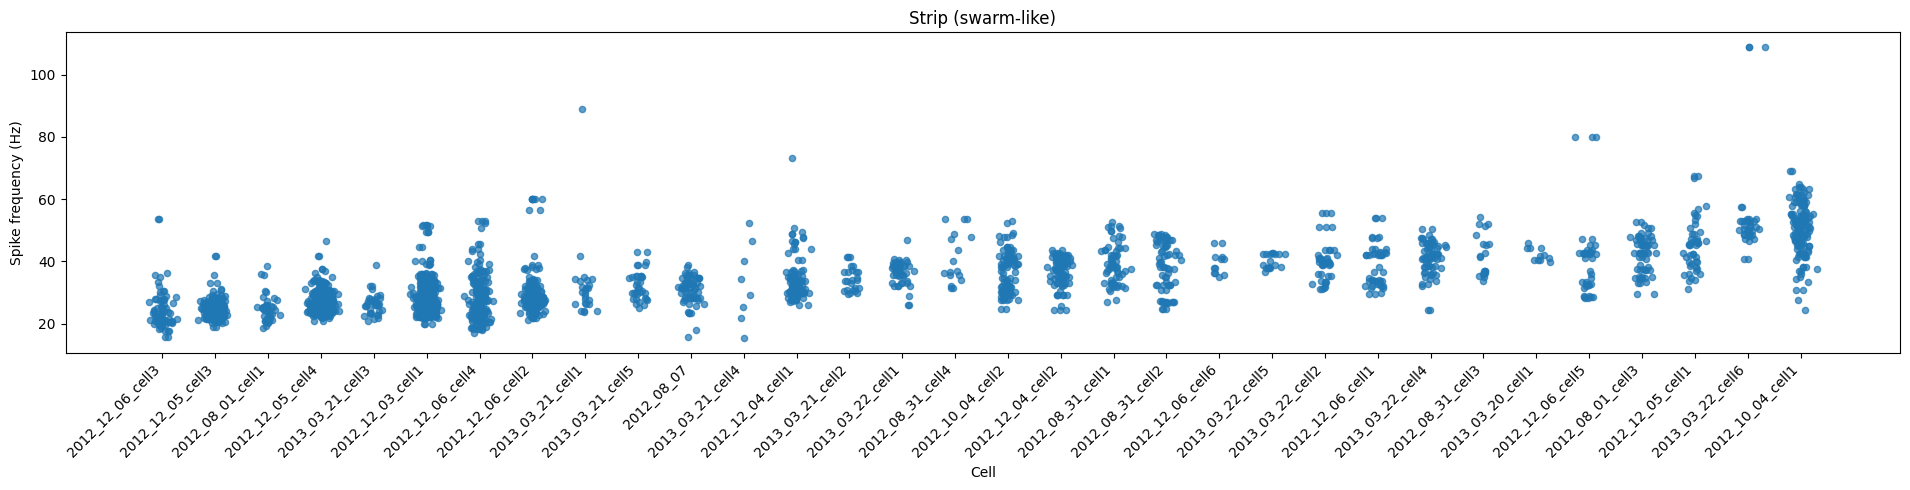

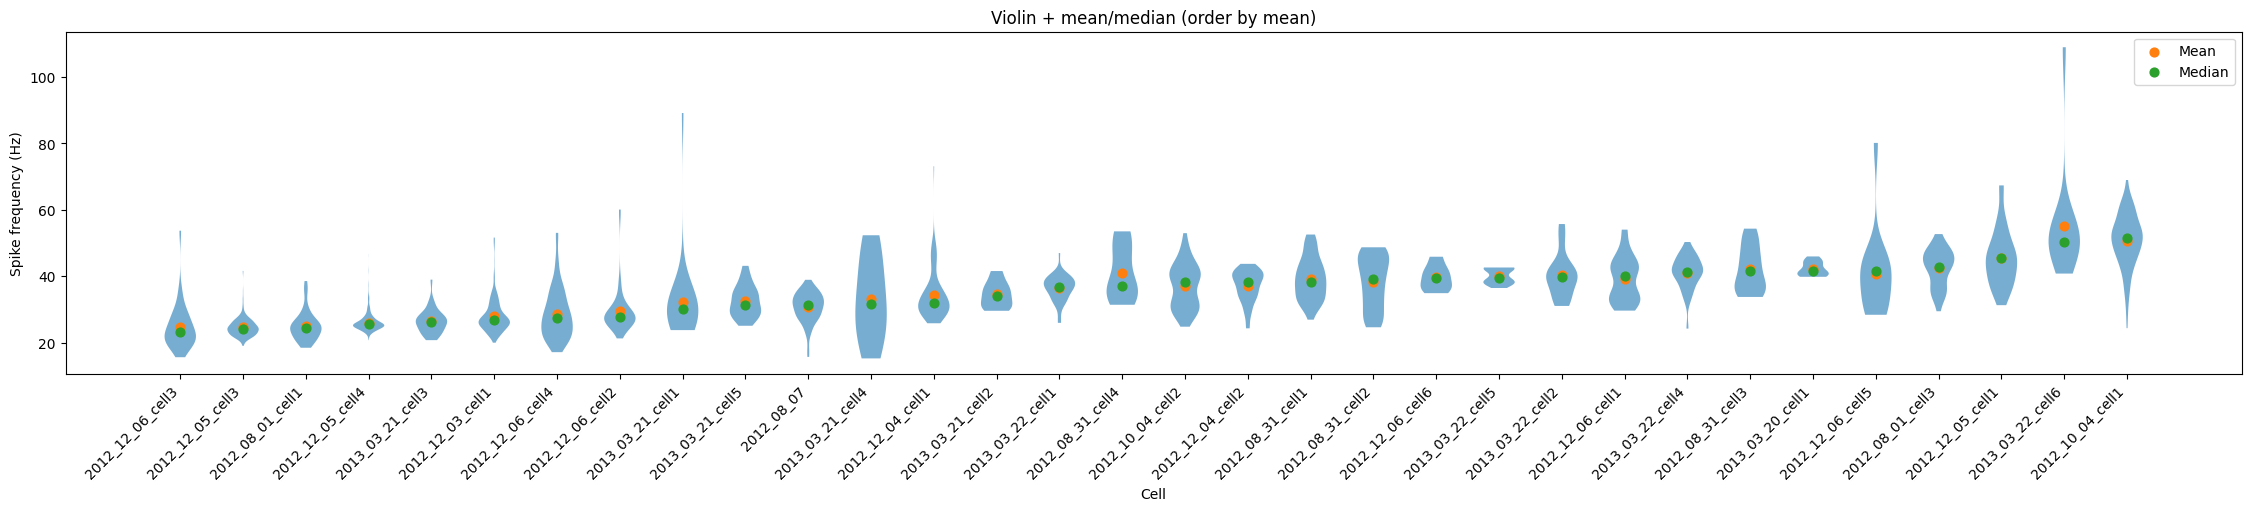

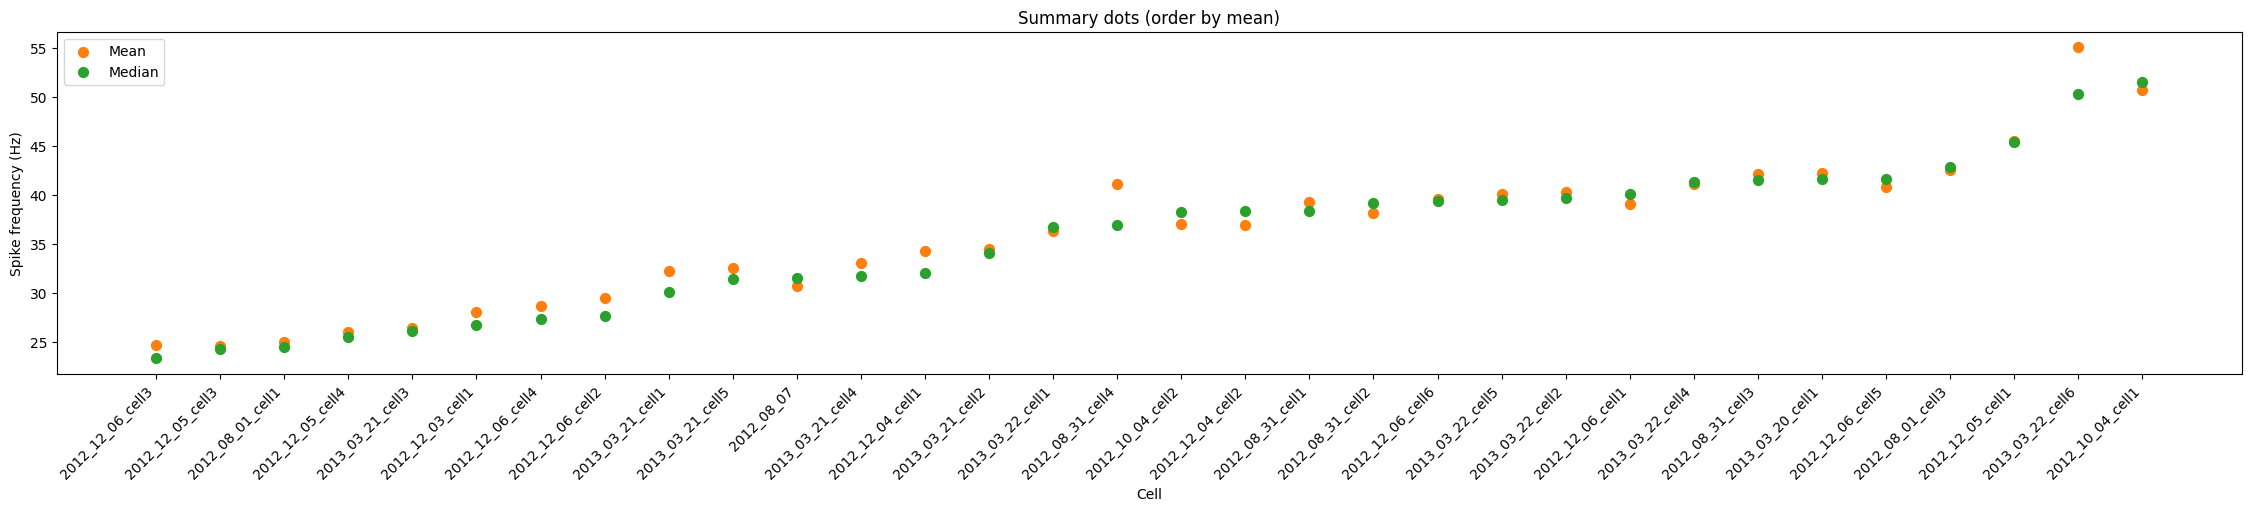

In [26]:
plot_all_views(all_spikes_clean, order_by="mean")

# Positional (since order_by is 2nd arg)
plot_all_views(all_spikes_clean, "median")



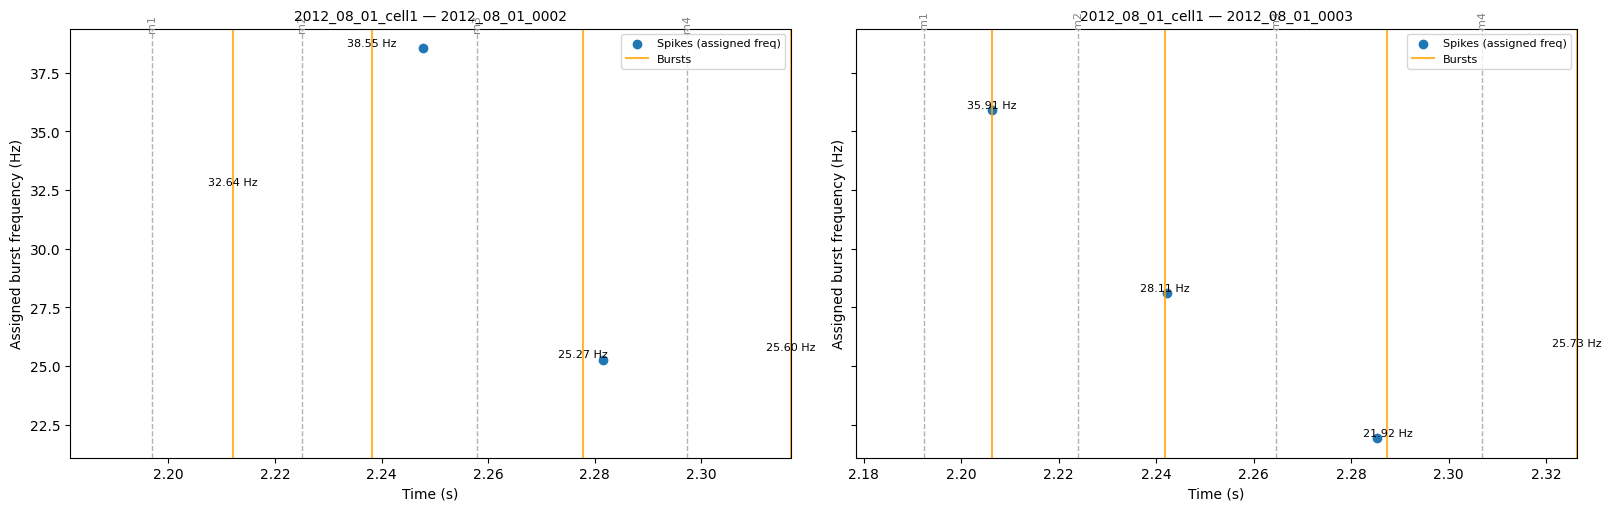

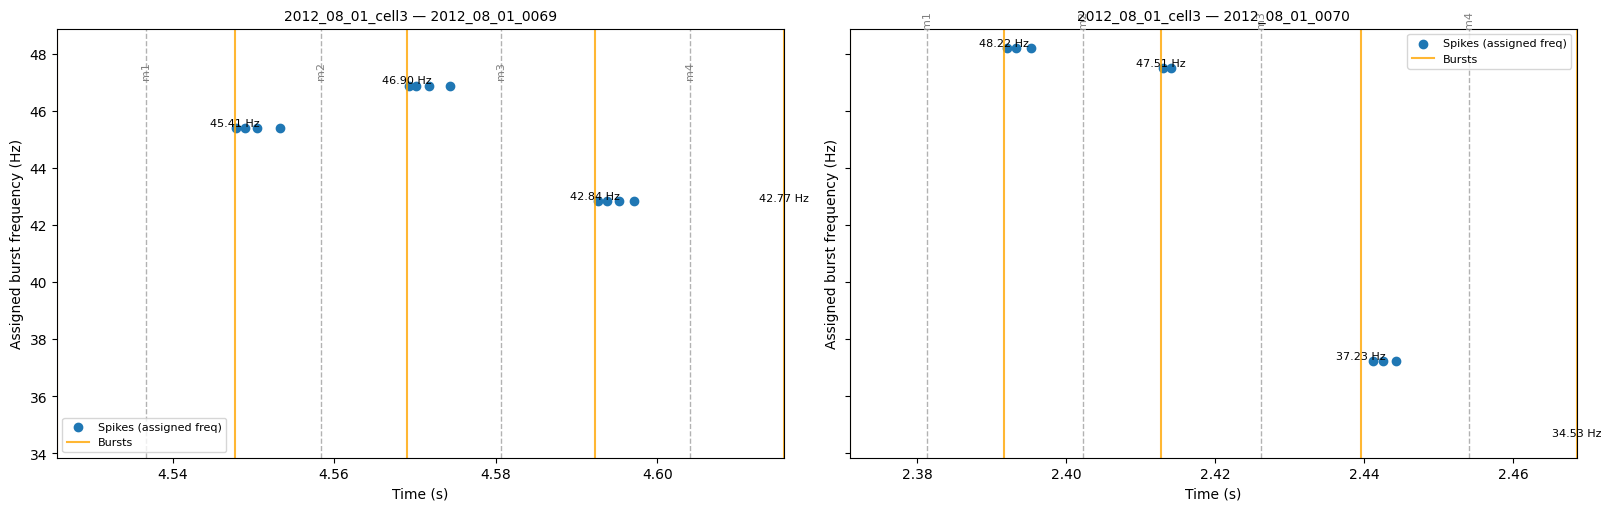

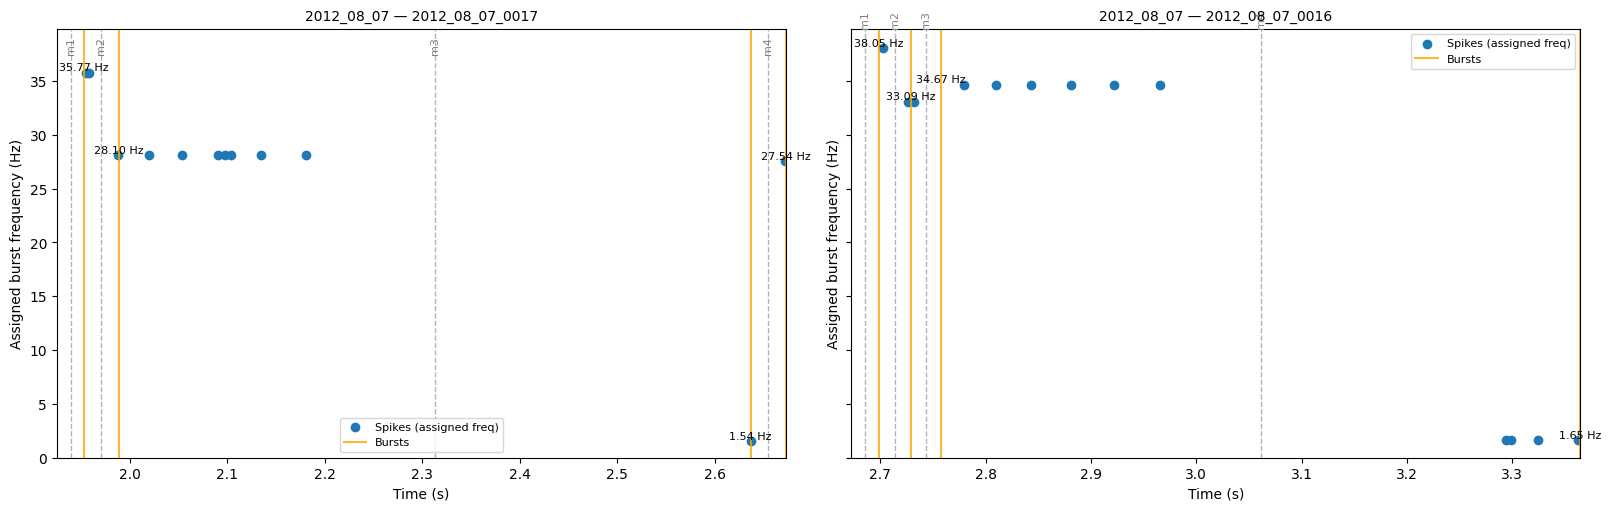

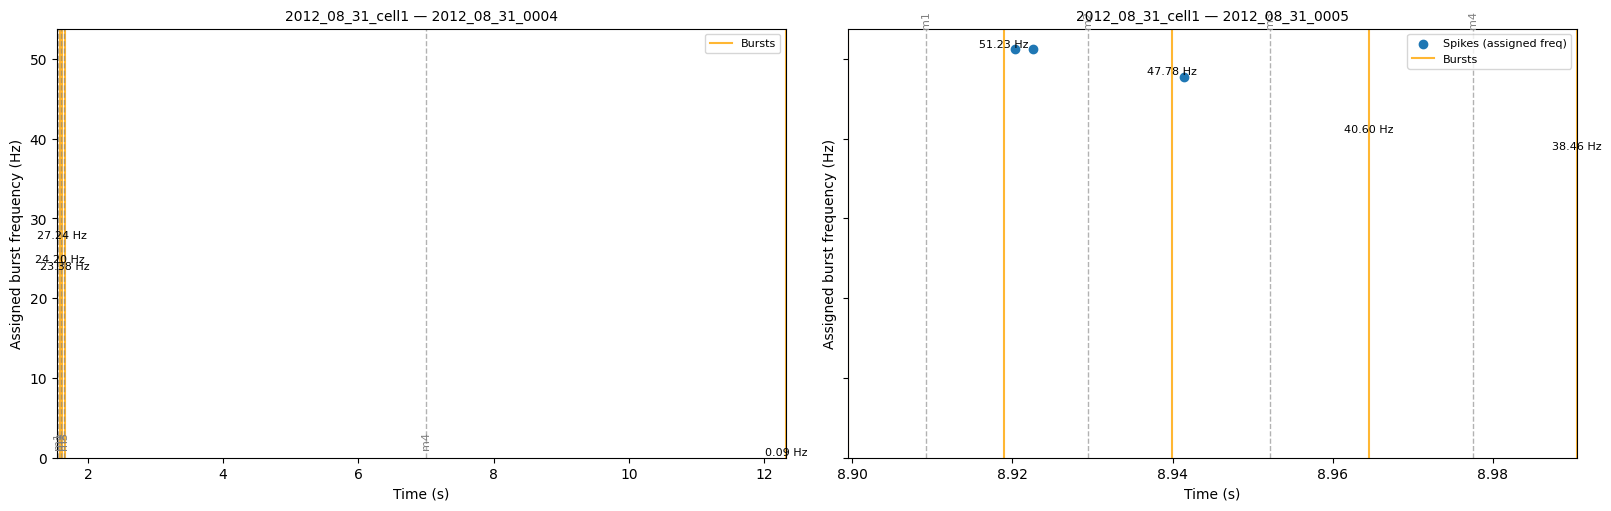

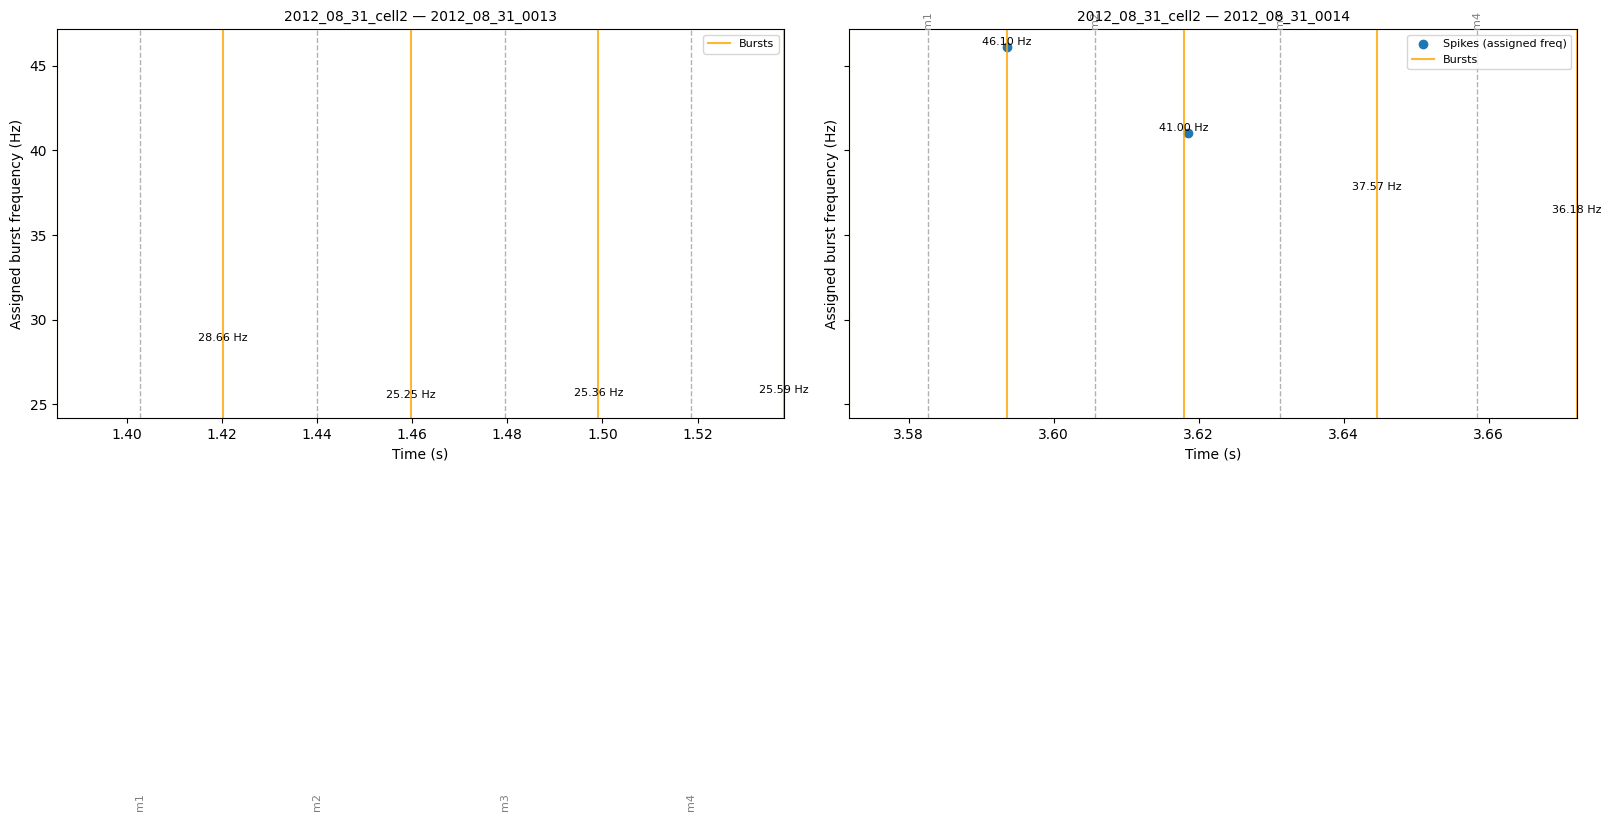

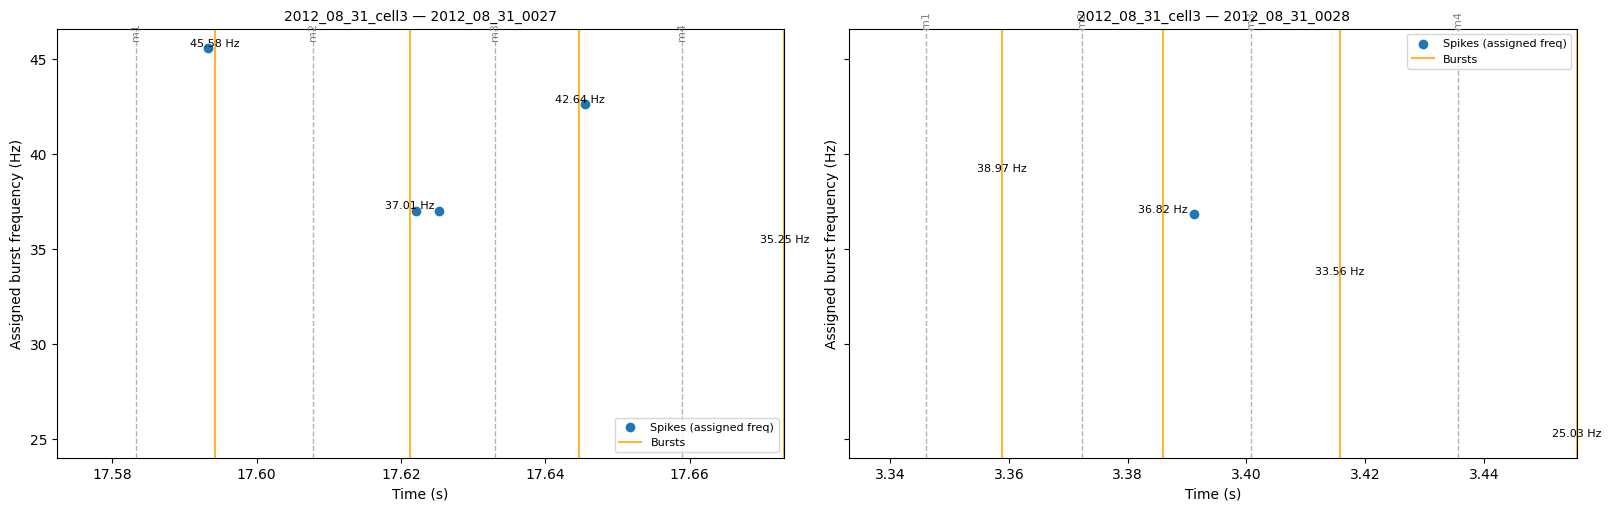

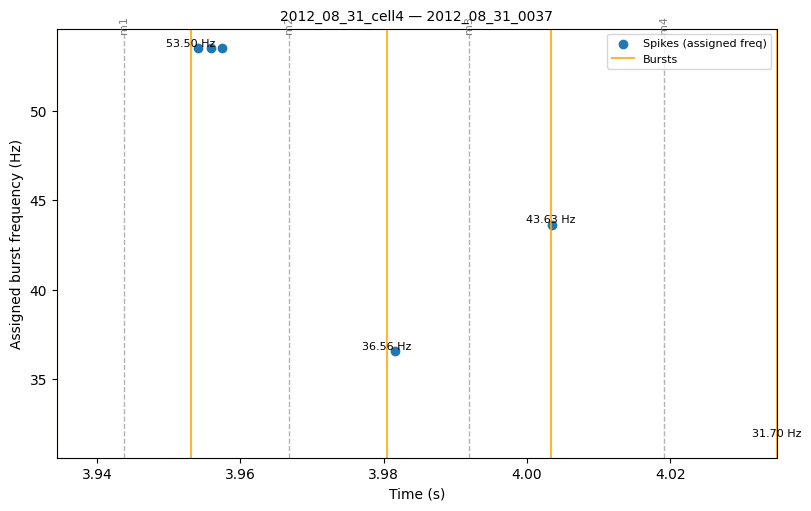

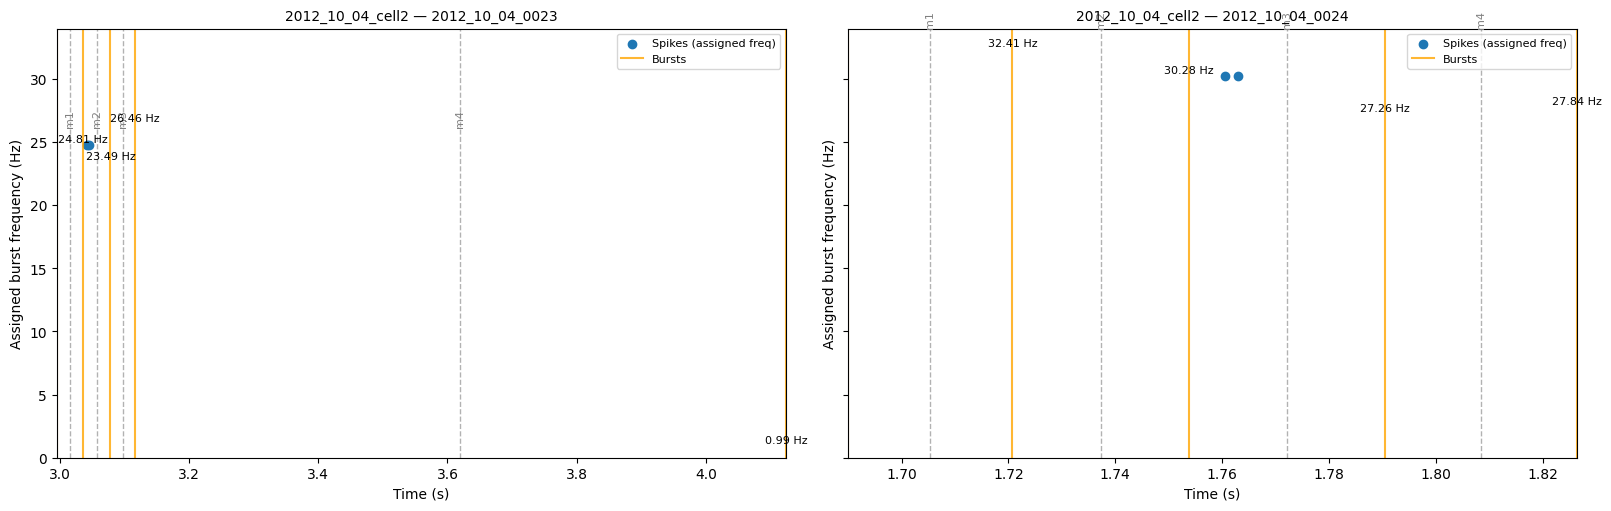

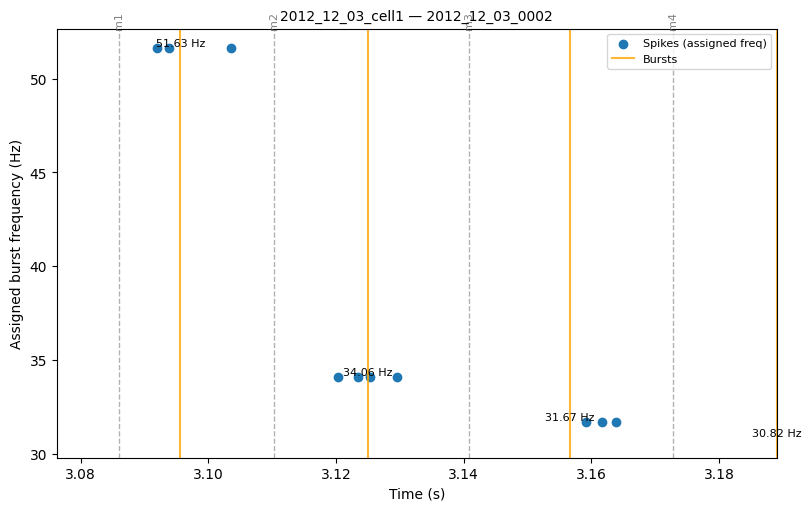

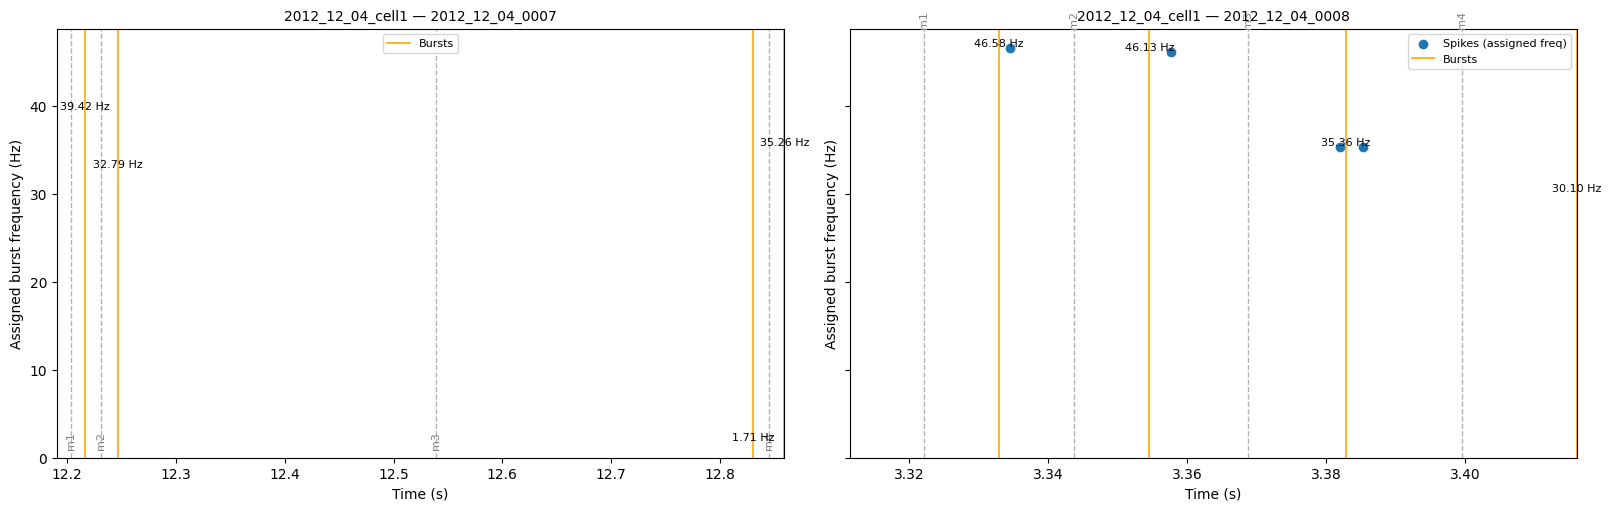

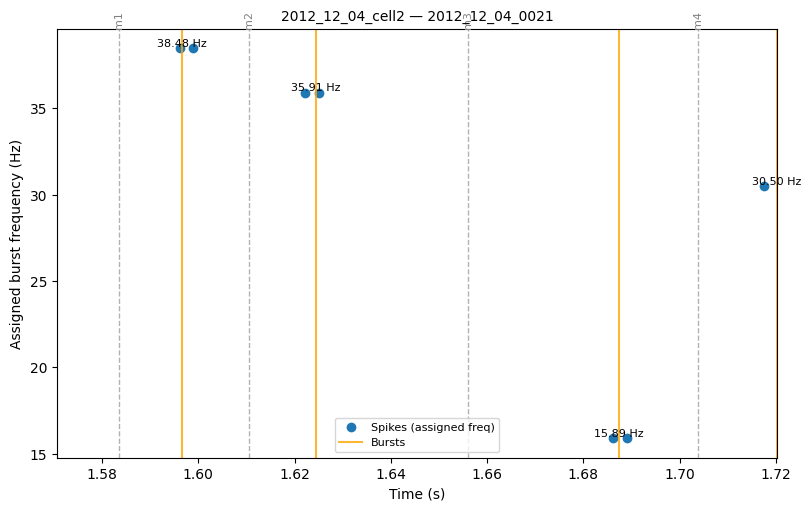

/Users/Haley/Desktop/murray-neuroscience-lab/neuro-venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


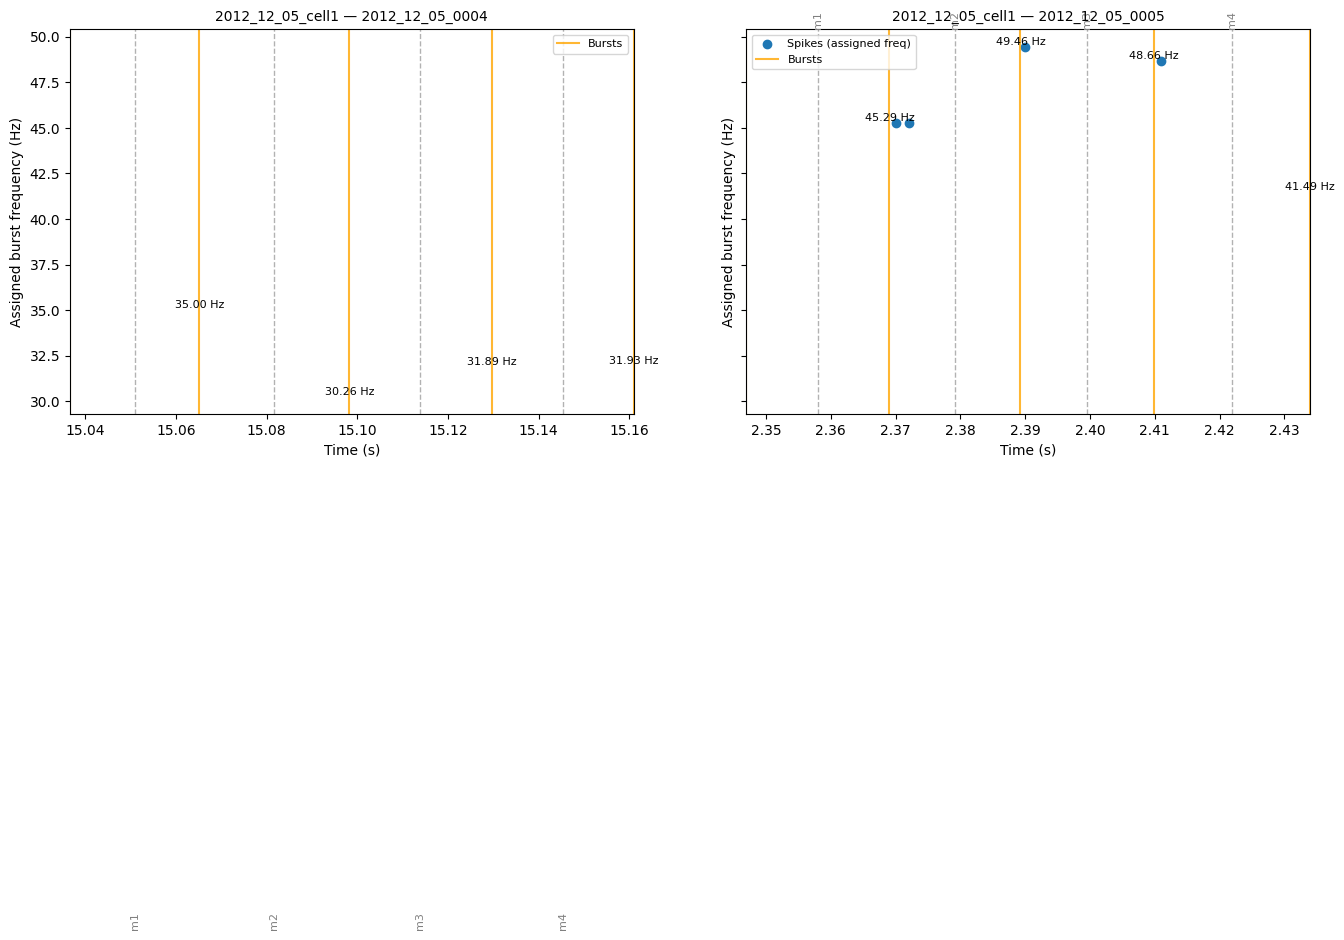

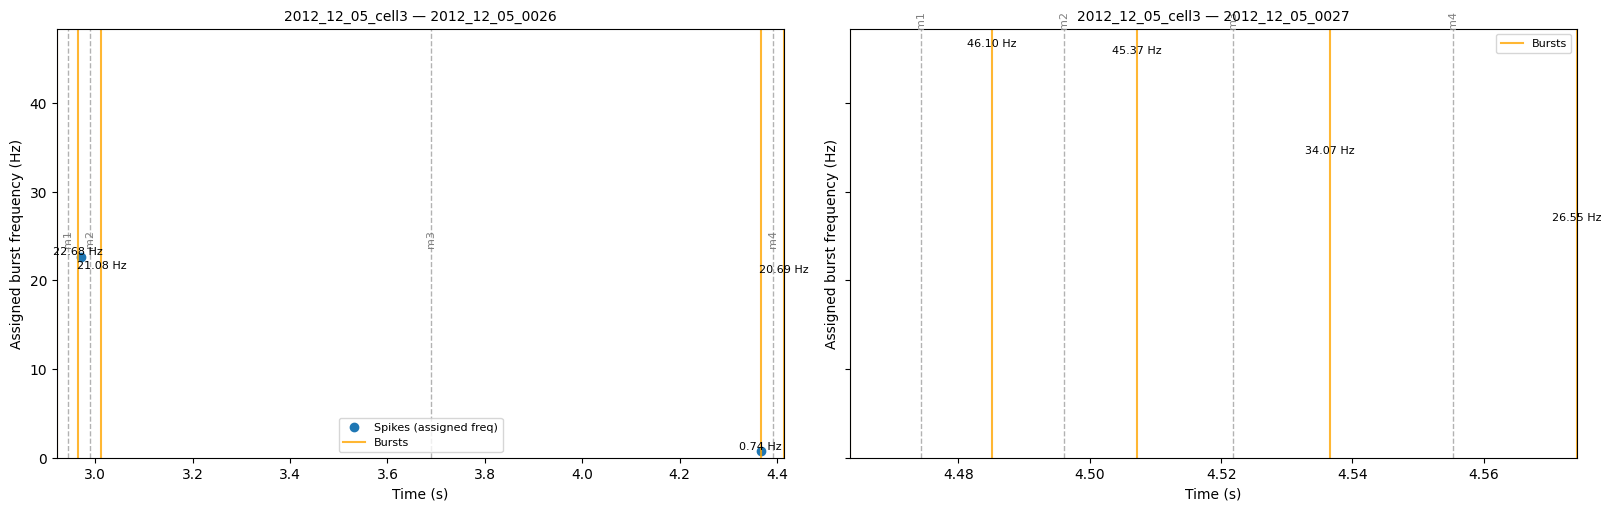

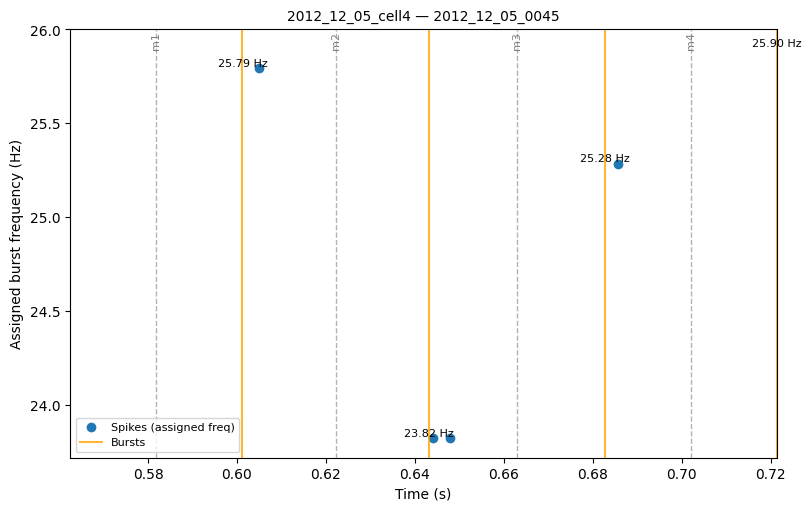

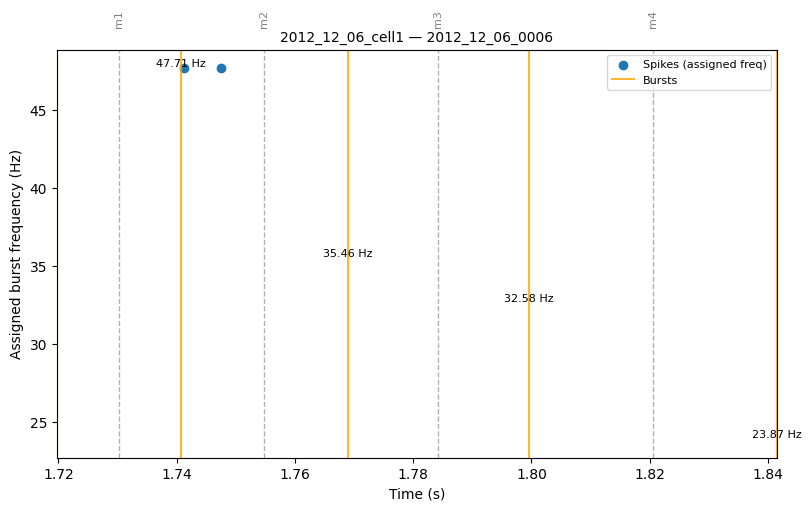

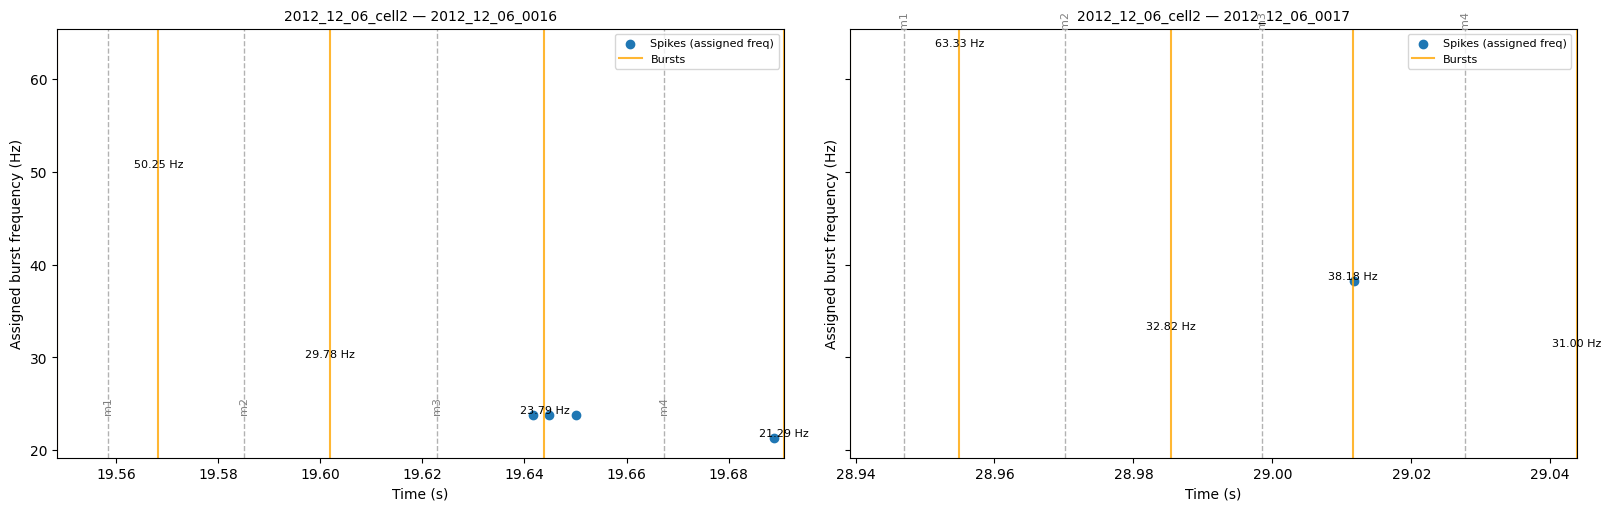

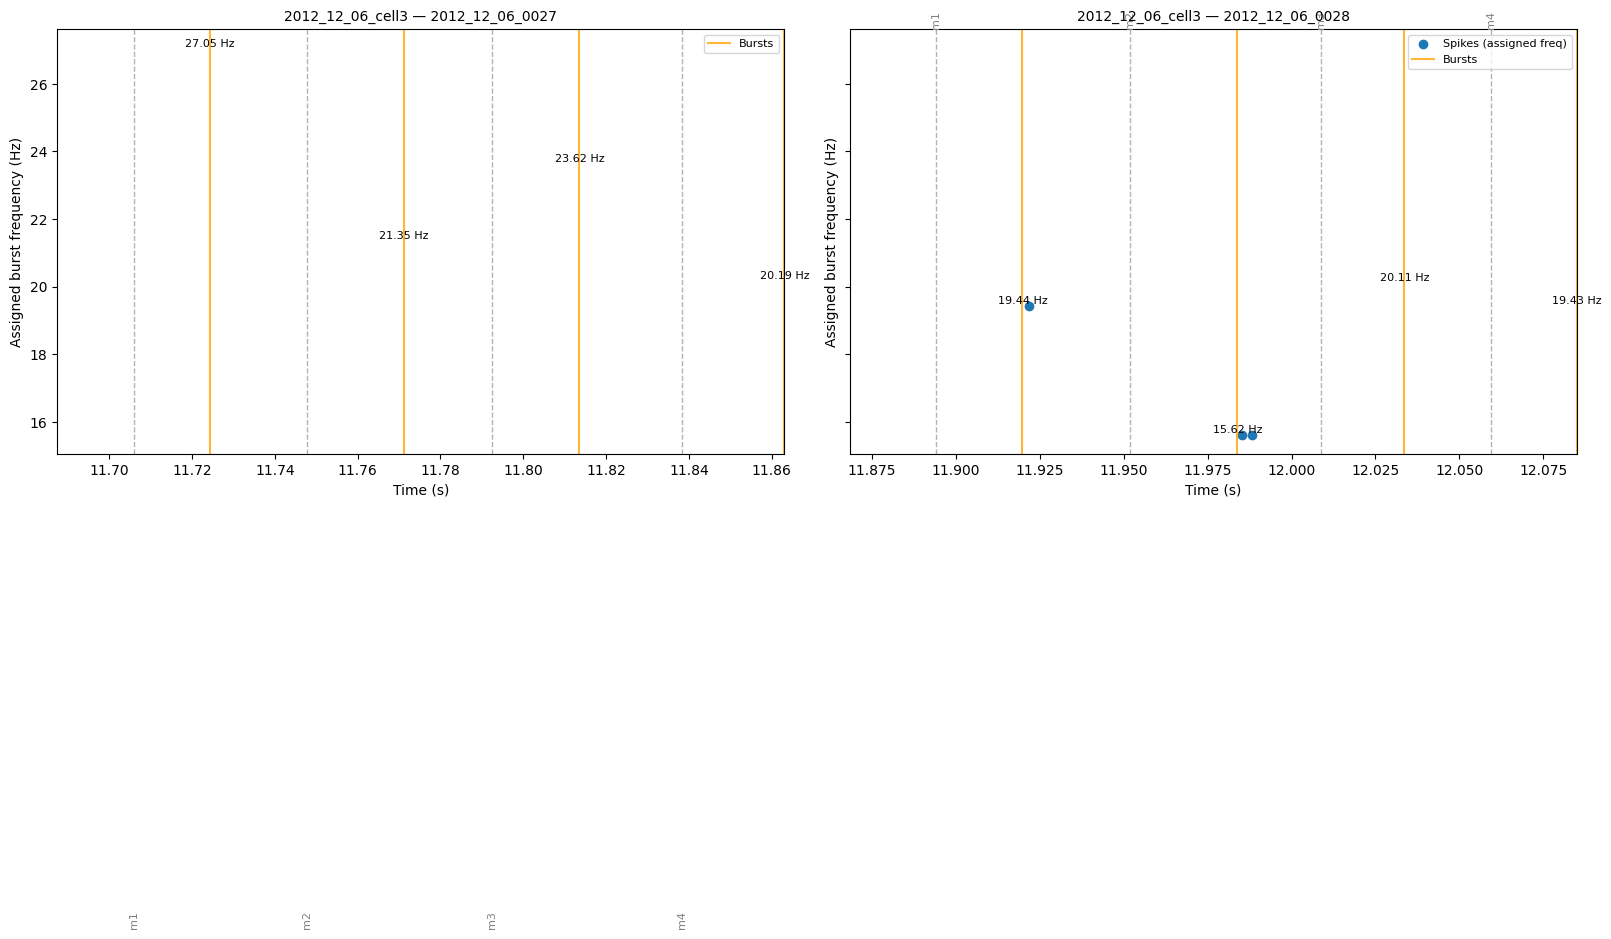

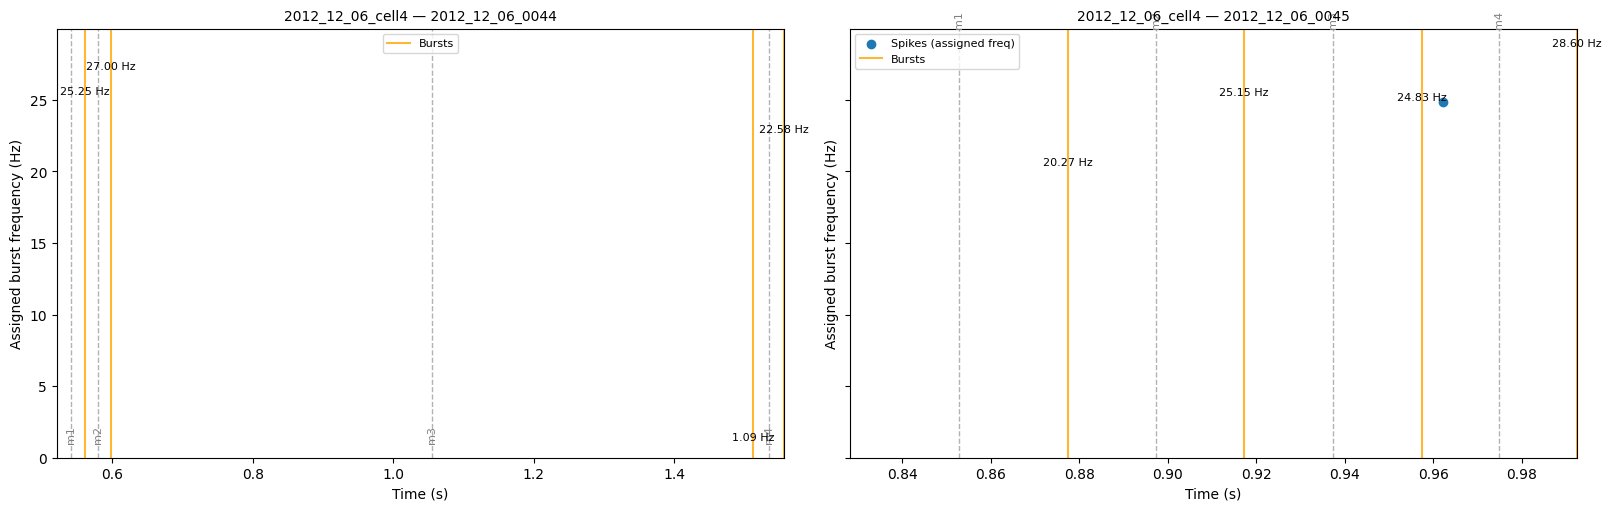

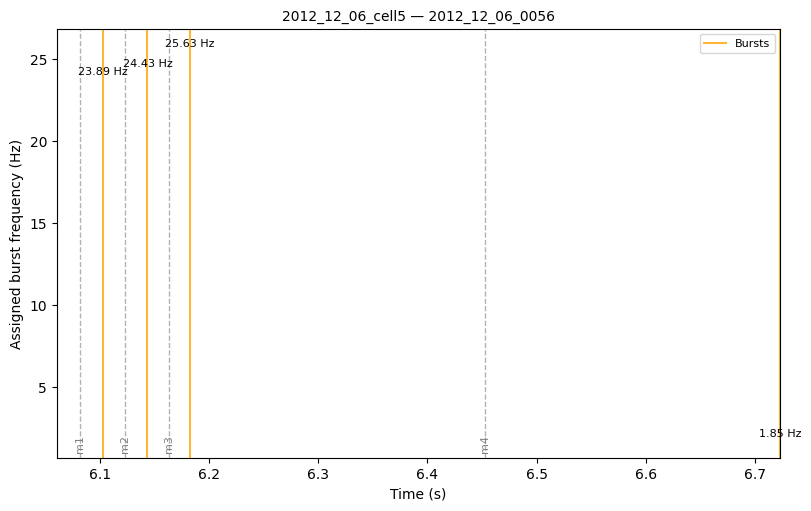

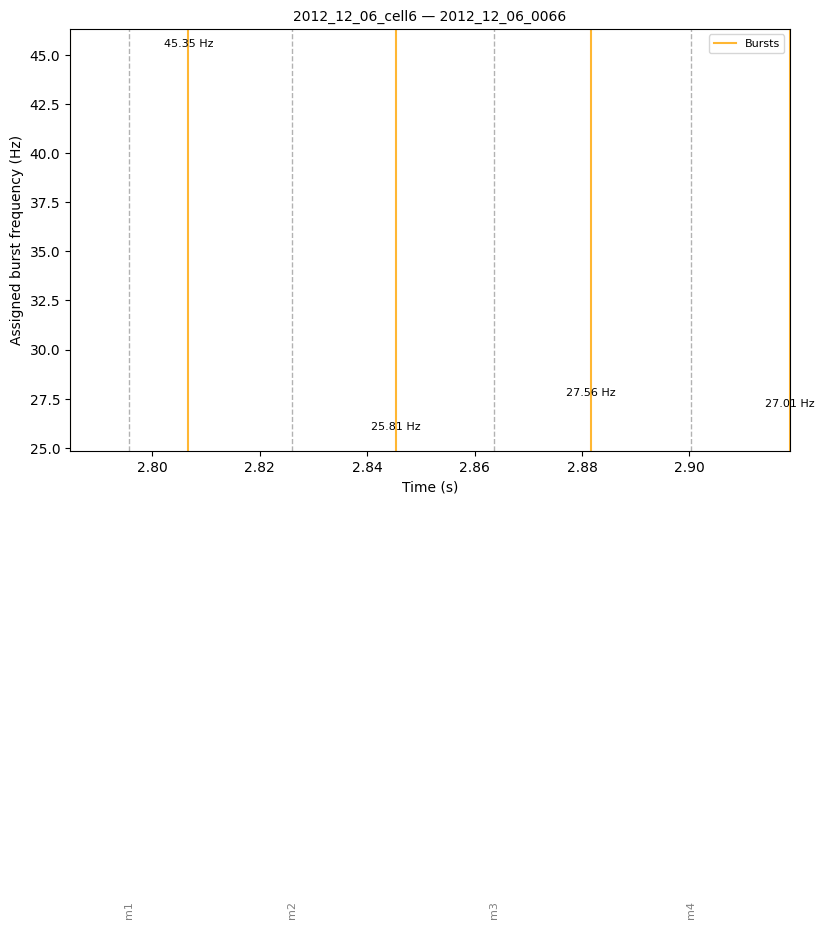

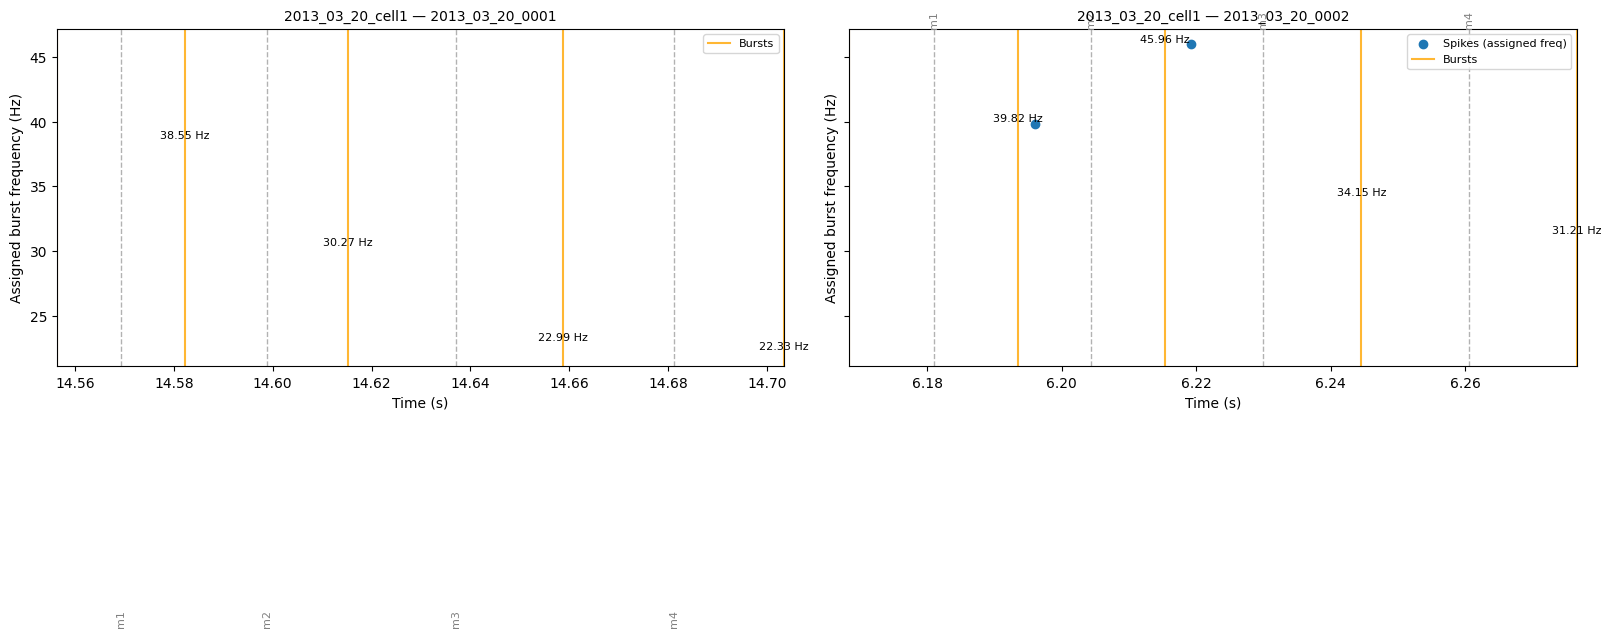

/Users/Haley/Desktop/murray-neuroscience-lab/neuro-venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


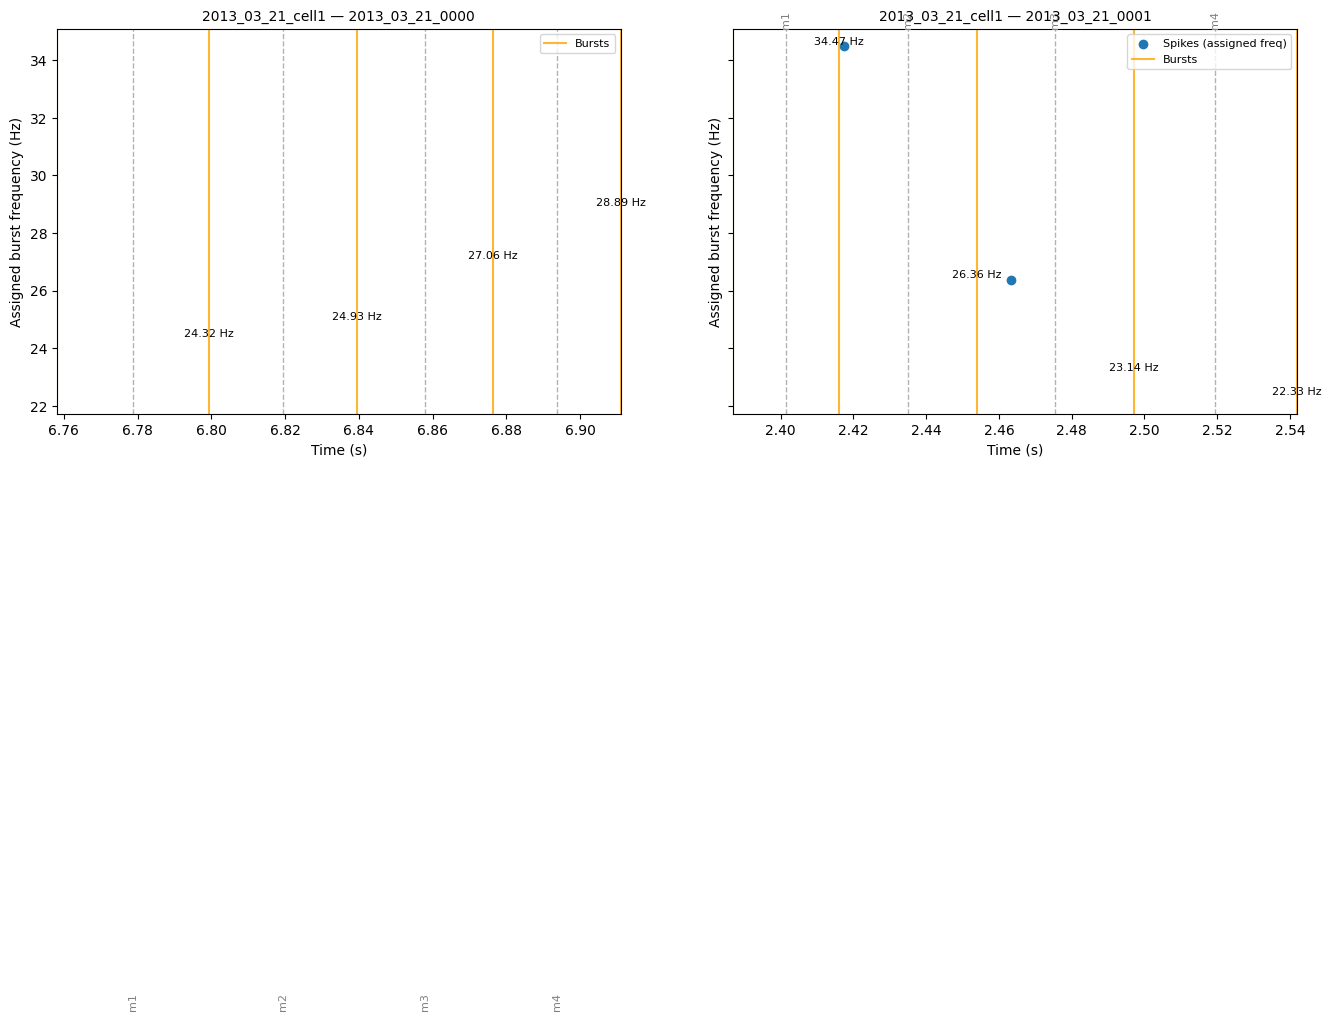

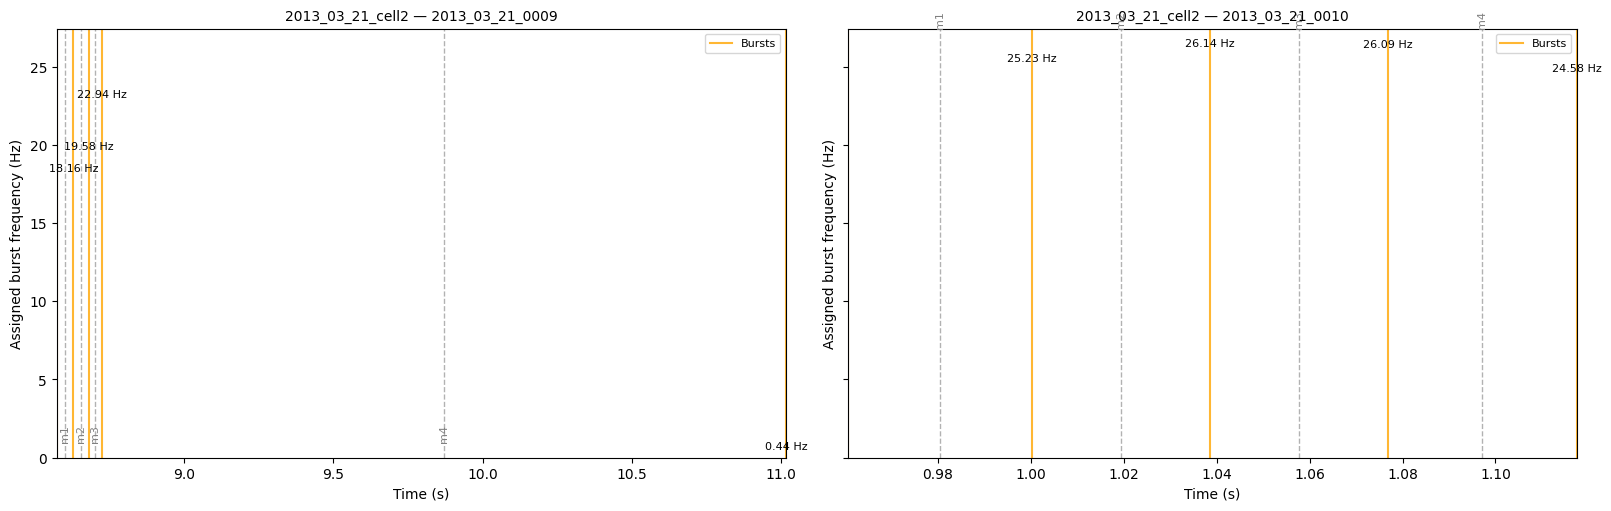

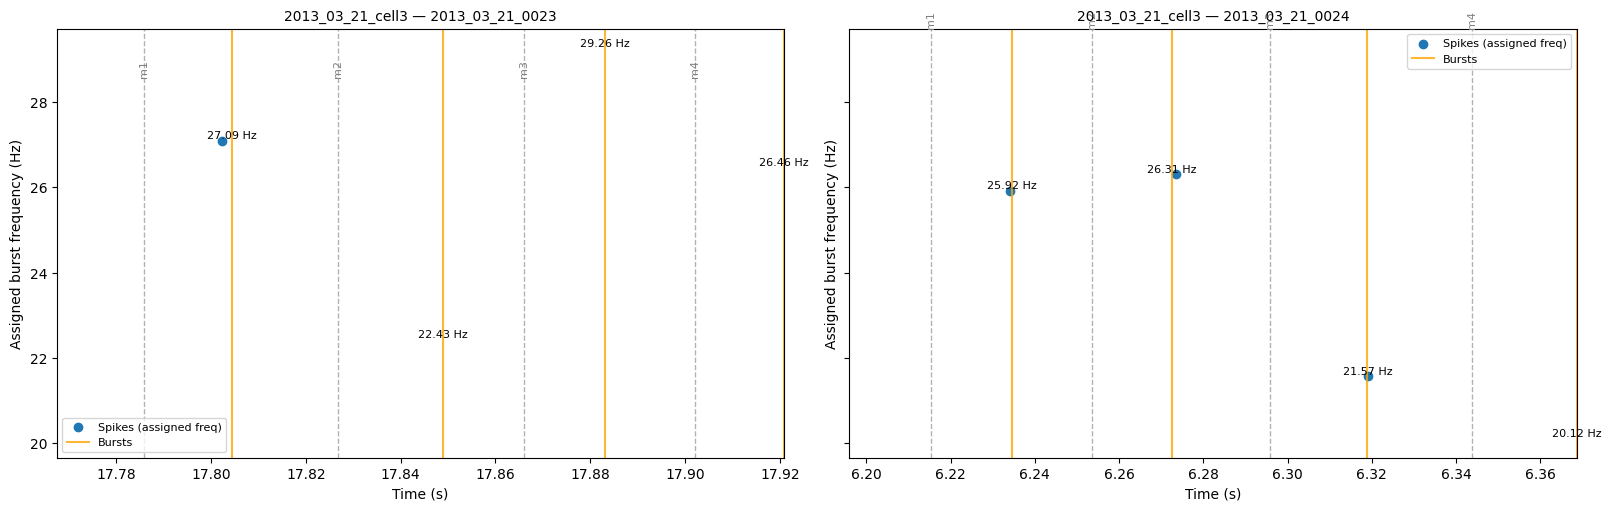

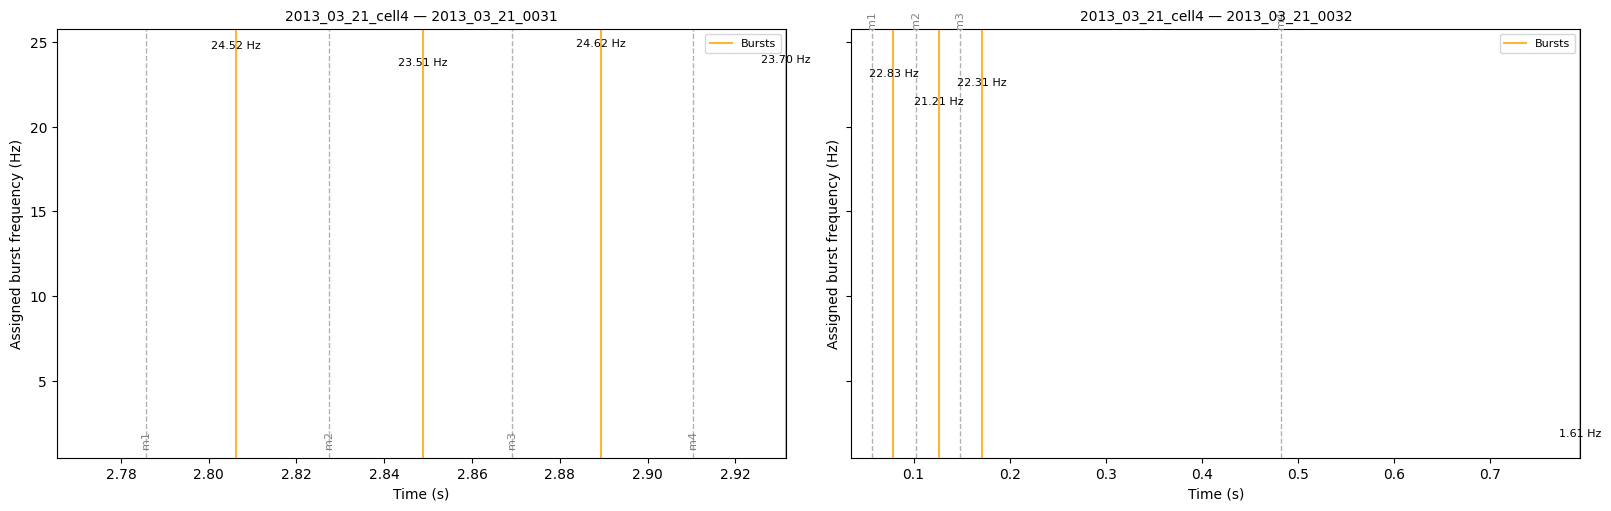

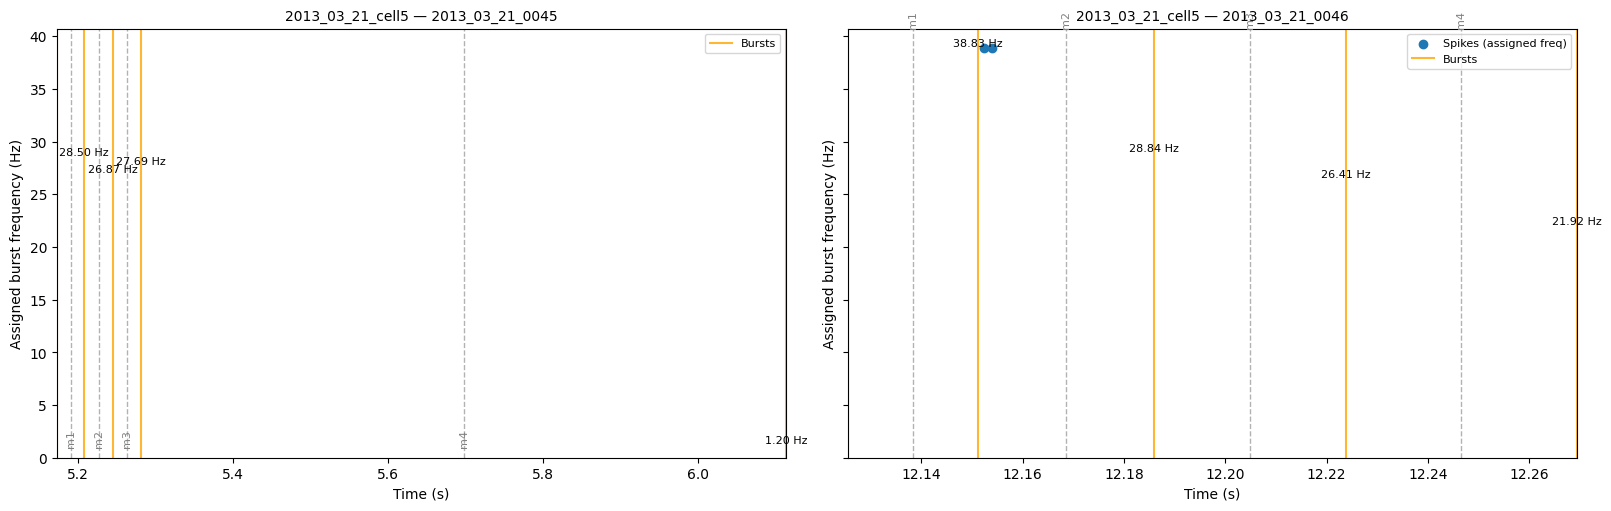

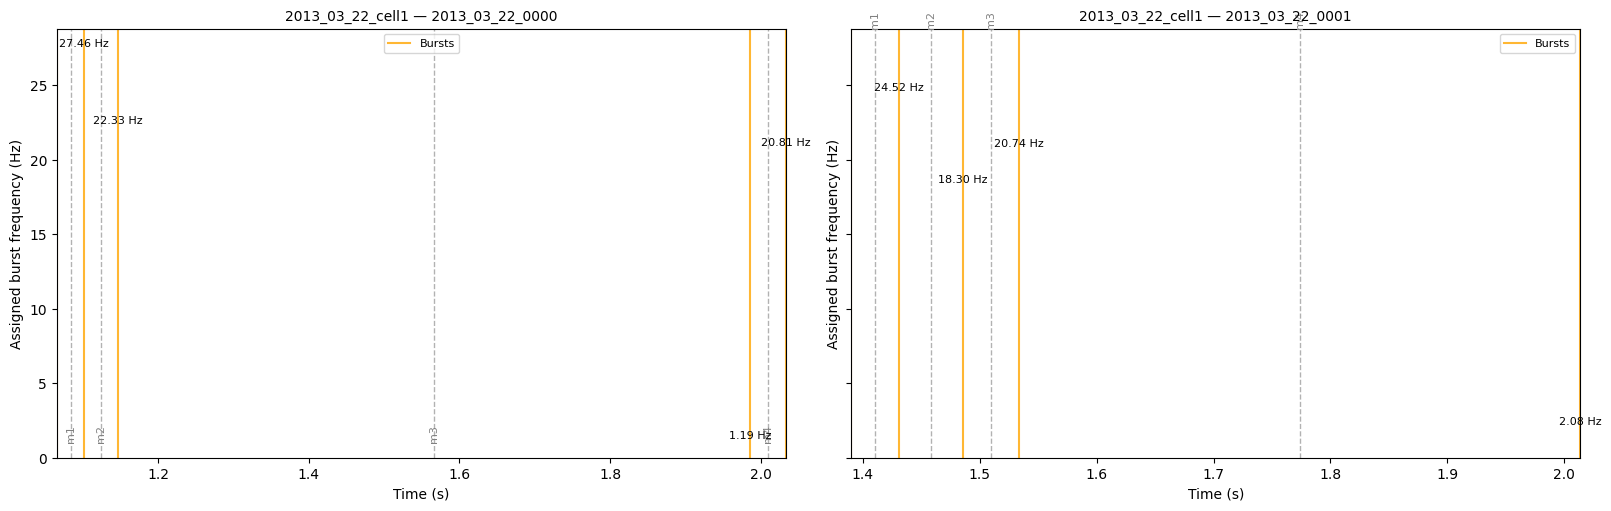

/Users/Haley/Desktop/murray-neuroscience-lab/neuro-venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


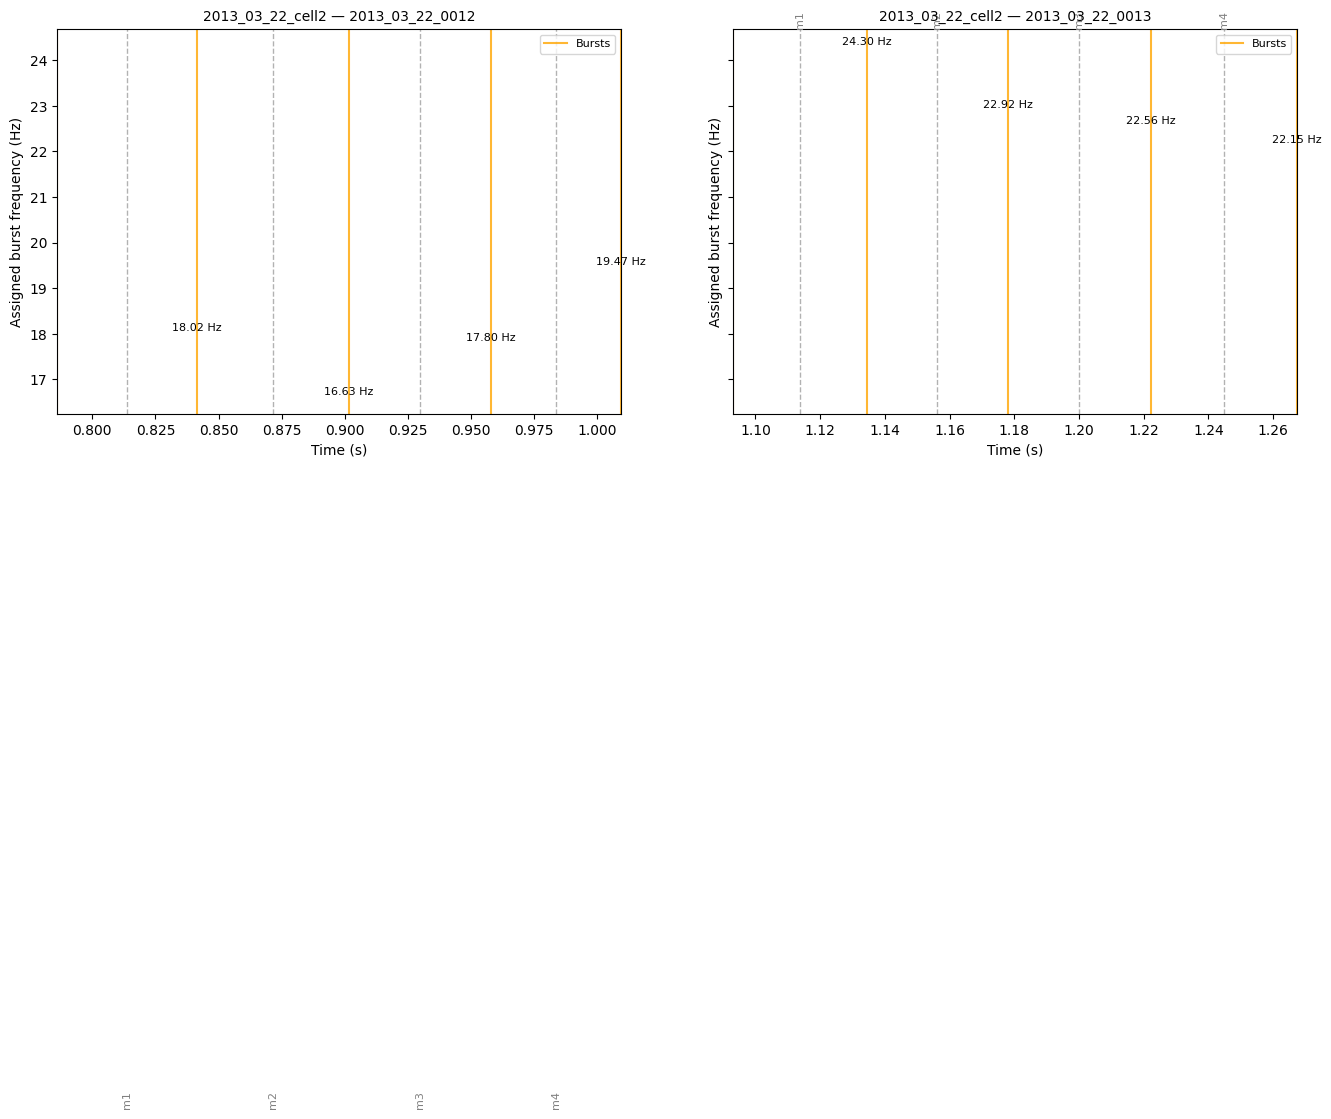

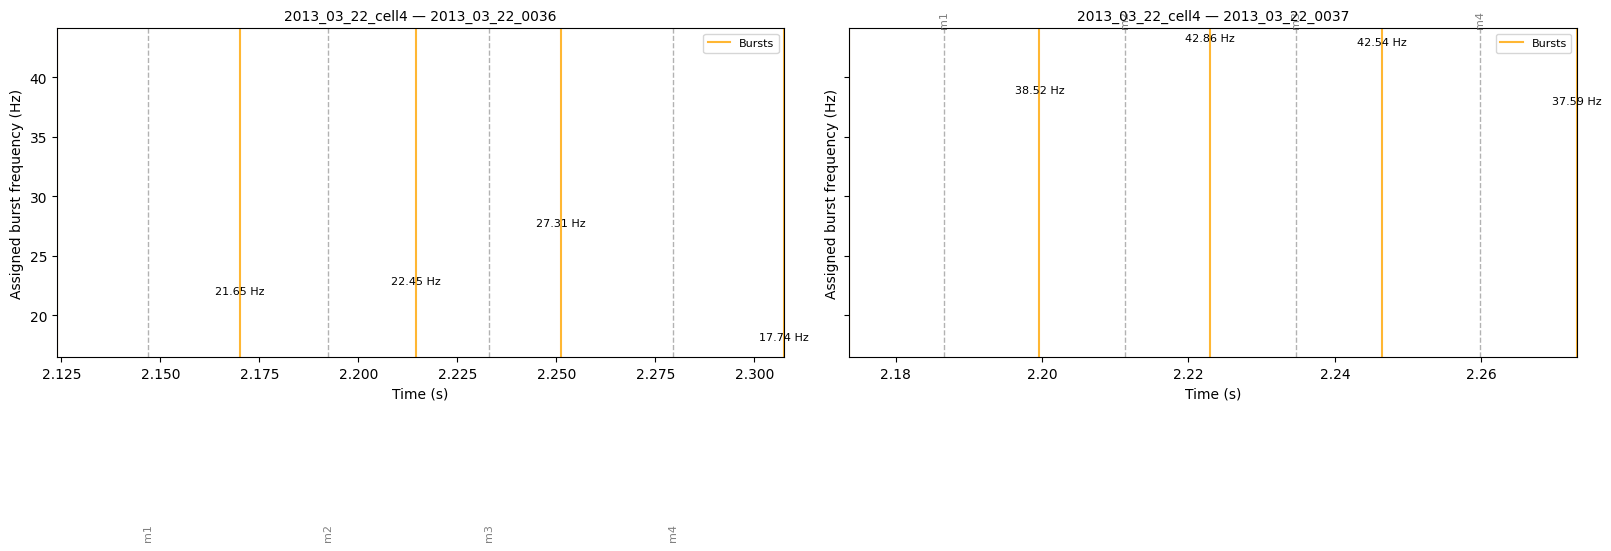

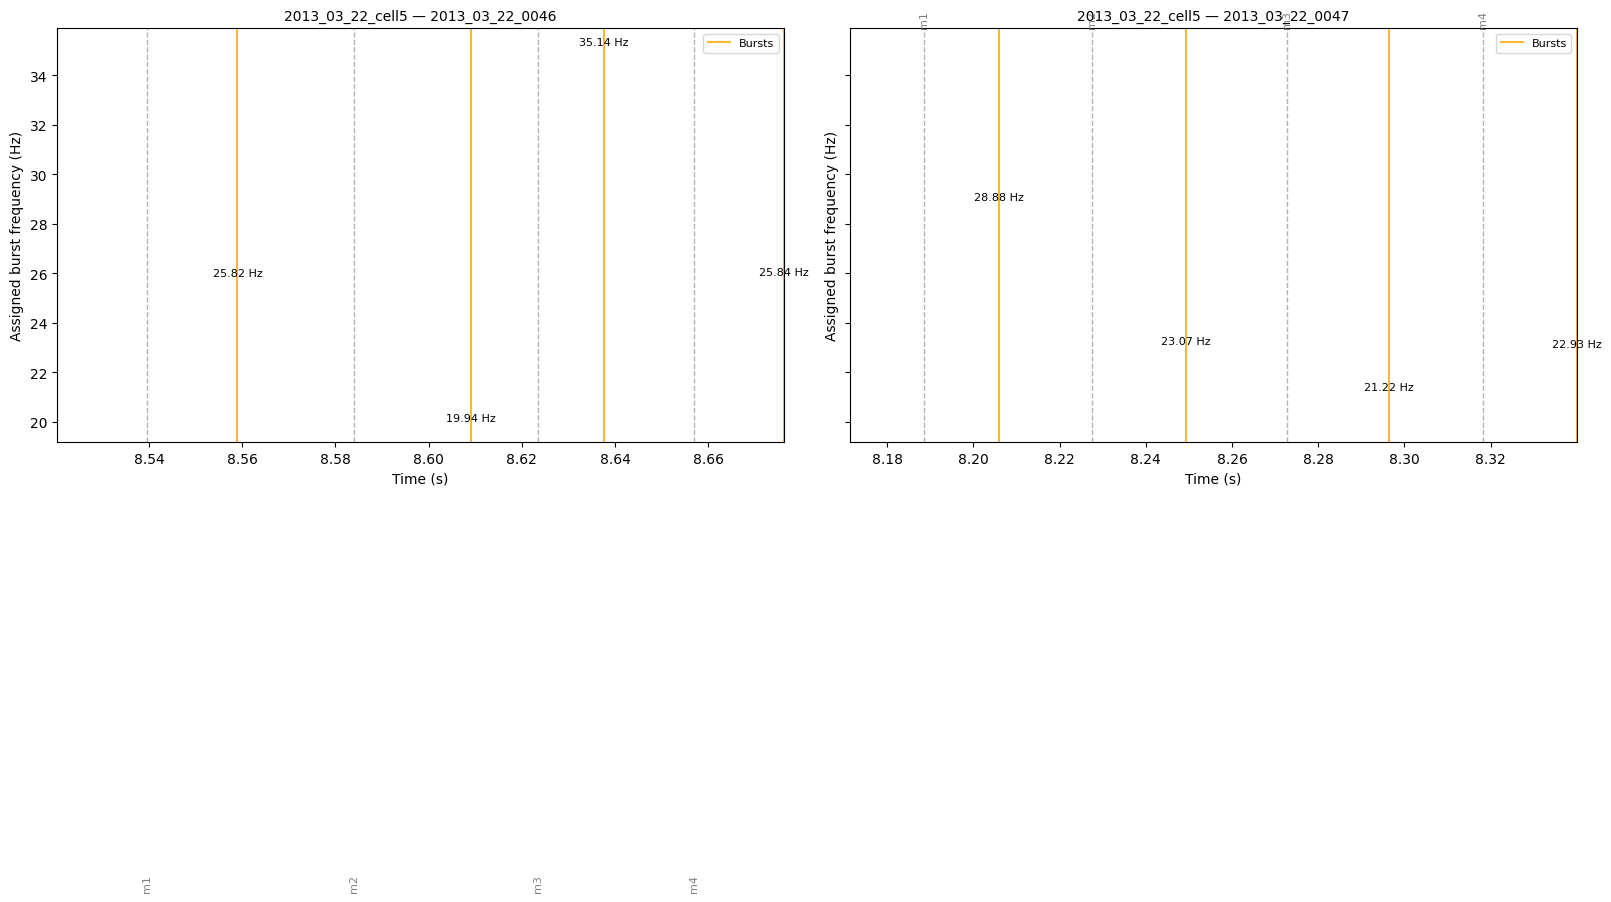

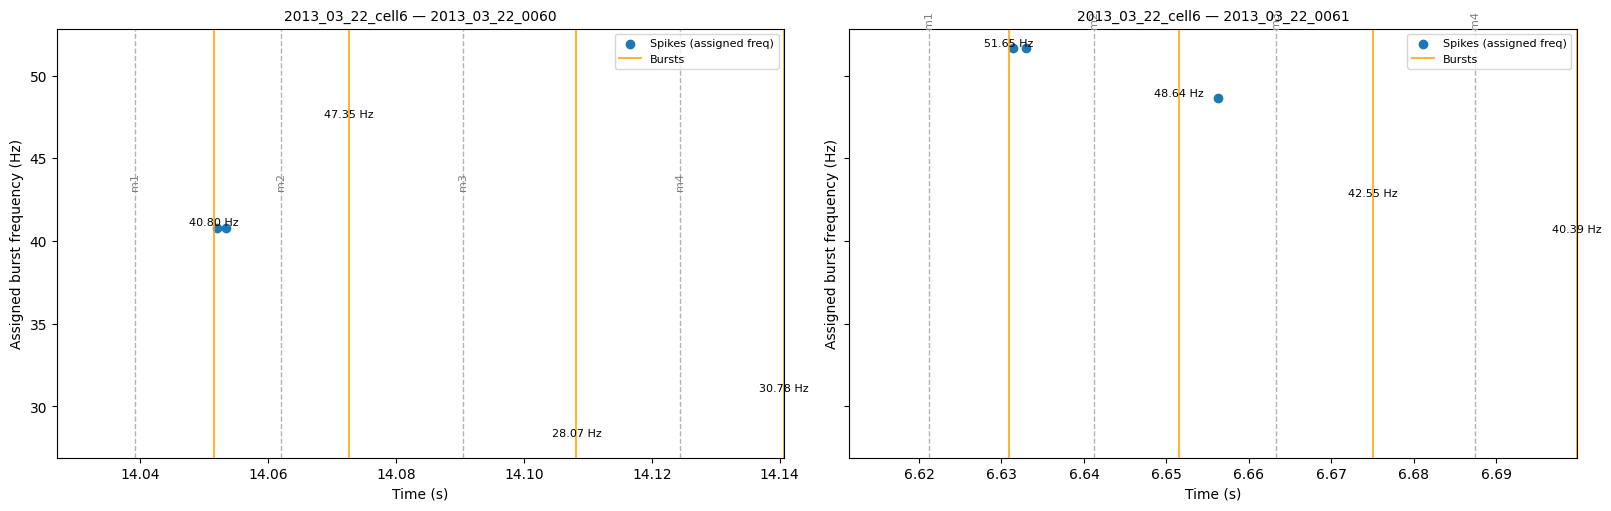

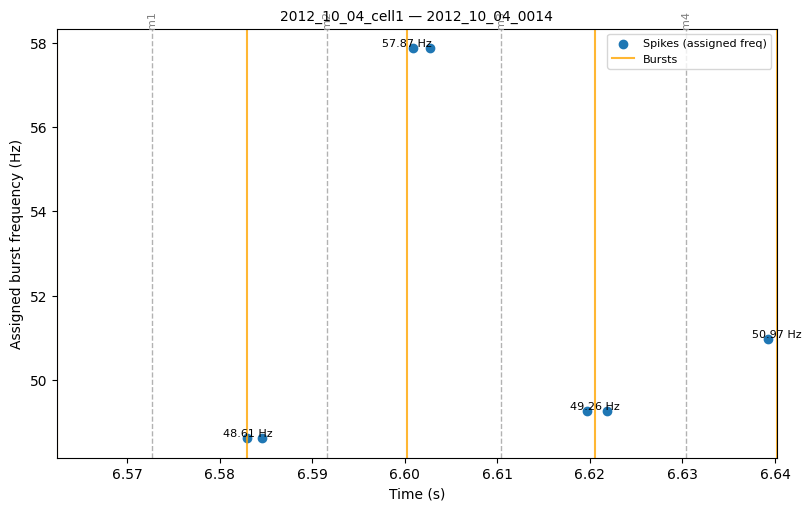

In [106]:
for sheet_name, sdf in cell_attached_dict.items():
    plot_sheet_first5_bursts(sdf, title_prefix=sheet_name)


In [ ]:
# final spike freq graph
# visualize spike frequency per cell ordered by median spiking frequency. use dots to plot median frequency
# any cells with mean less than 35 hz label slow and above that label fast 

In [2]:

# Compute per-cell stats from all_spikes_clean
cell_stats = (
    all_spikes_clean
    .groupby("cell")["spike_frequency"]
    .agg(mean_freq="mean", median_freq="median")
    .reset_index()
    .sort_values("median_freq")
)

# Label slow (mean < 35 Hz) vs fast (mean >= 35 Hz)
cell_stats["speed_label"] = np.where(cell_stats["mean_freq"] < 35, "slow", "fast")
# color_map = {"fast": "#2b558e", "slow": "#6ac4d6"}
c_e_fast = "#9AA0A6"   # fast excitatory shown in gray
c_e_slow = "#9AA0A6"   # slow excitatory shown in gray
color_map = {"fast": c_e_fast, "slow": c_e_slow}

# Build ordered cell list
ordered_cells = cell_stats["cell"].tolist()
cell_to_x = {cell: i for i, cell in enumerate(ordered_cells)}
cell_to_color = cell_stats.set_index("cell")["speed_label"].map(color_map).to_dict()
cell_to_median = cell_stats.set_index("cell")["median_freq"].to_dict()

fig, ax = plt.subplots(figsize=(14, 6))

# Draw one horizontal dash per spike
dash_half = 0.3
for _, row in all_spikes_clean.iterrows():
    cell = row["cell"]
    freq = row["spike_frequency"]
    if cell not in cell_to_x or pd.isna(freq):
        continue
    x = cell_to_x[cell]
    color = cell_to_color.get(cell, "gray")
    ax.plot([x - dash_half, x + dash_half], [freq, freq],
            color=color, linewidth=0.6, alpha=0.35, solid_capstyle="butt", zorder=2)

# Median dots on top
for cell, x in cell_to_x.items():
    median = cell_to_median.get(cell)
    color = cell_to_color.get(cell, "gray")
    if median is not None:
        ax.scatter(x, median, color=color, s=50, zorder=5, edgecolors="black", linewidth=0.6)

# 35 Hz threshold line
ax.axhline(35, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="35 Hz threshold")

ax.set_xticks(range(len(ordered_cells)))
ax.set_xticklabels(ordered_cells, rotation=75, ha="right", fontsize=8)
ax.set_ylabel("Spike frequency (Hz)")
ax.set_title("Spike frequency per cell (ordered by median)\nDashes = individual spikes; dot = median")
ax.grid(axis="y", alpha=0.2)

legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color_map["fast"], markersize=9, label="Fast (mean ≥ 35 Hz)"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color_map["slow"], markersize=9, label="Slow (mean < 35 Hz)"),
]
ax.legend(handles=legend_handles, frameon=False)

plt.tight_layout()
plt.show()


NameError: name 'all_spikes_clean' is not defined

## Burst-level spike counts vs frequency (Fast vs Slow MN)

Each point below is one ventral root burst:
- **x** = associated ventral root burst frequency
- **y** = total number of spikes for that MN during that burst

Fast/slow groups are assigned from `cell_types_df['Motoneuron']`:
- labels containing `primary` → `fast`
- labels containing `secondary` → `slow`

Black dots are mean spike counts within your 4 frequency bins.

In [77]:
# Build one row per burst per MN
required_cols = {"cell", "Trace name", "burst_index", "spike_frequency"}
missing_cols = required_cols - set(all_spikes_clean.columns)
if missing_cols:
    raise ValueError(f"all_spikes is missing required columns: {missing_cols}")

burst_points = (
    all_spikes_clean
    .dropna(subset=["spike_frequency", "burst_index", "cell", "Trace name"])
    .copy()
)
burst_points["burst_index"] = pd.to_numeric(burst_points["burst_index"], errors="coerce")
burst_points["spike_frequency"] = pd.to_numeric(burst_points["spike_frequency"], errors="coerce")
burst_points = burst_points.dropna(subset=["burst_index", "spike_frequency"])

burst_points = (
    burst_points
    .groupby(["cell", "Trace name", "burst_index"], as_index=False)
    .agg(
        burst_frequency_hz=("spike_frequency", "median"),
        burst_spike_count=("spike_frequency", "size")
    )
)

# Map cells to fast/slow using Motoneuron labels in cell_types_df
meta = cell_types_df[["Cell", "Motoneuron"]].drop_duplicates().copy()

def motoneuron_to_speed(label):
    s = str(label).strip().lower()
    if "primary" in s:
        return "fast"
    if "secondary" in s:
        return "slow"
    return np.nan

meta["speed_group"] = meta["Motoneuron"].apply(motoneuron_to_speed)

burst_points = burst_points.merge(
    meta[["Cell", "speed_group"]],
    left_on="cell",
    right_on="Cell",
    how="left"
).drop(columns=["Cell"])

burst_points = burst_points.dropna(subset=["speed_group"])

# Frequency bins: 15–25, 25–35, 35–45, 45+
freq_bin_edges = [15, 25, 35, 45, np.inf]
freq_bin_labels = ["15–25", "25–35", "35–45", "45+"]

burst_points["freq_bin"] = pd.cut(
    burst_points["burst_frequency_hz"],
    bins=freq_bin_edges,
    labels=freq_bin_labels,
    include_lowest=True,
    right=False
)

bin_centers = {
    "15–25": 20.0,
    "25–35": 30.0,
    "35–45": 40.0,
    "45+": 50.0
}

bin_means = (
    burst_points
    .dropna(subset=["freq_bin"])
    .groupby(["speed_group", "freq_bin"], observed=True, as_index=False)
    .agg(
        mean_spike_count=("burst_spike_count", "mean"),
        std_spike_count=("burst_spike_count", "std"),
        n_bursts=("burst_spike_count", "size")
    )
)
bin_means["std_spike_count"] = bin_means["std_spike_count"].fillna(0.0)
bin_means["sem_spike_count"] = bin_means["std_spike_count"] / np.sqrt(bin_means["n_bursts"].clip(lower=1))
bin_means["bin_center_hz"] = bin_means["freq_bin"].astype(str).map(bin_centers)

print("Burst-level points:", burst_points.shape)
print(burst_points["speed_group"].value_counts(dropna=False))
print("\nBinned means (with SEM):")
display(bin_means.sort_values(["speed_group", "bin_center_hz"]))

Burst-level points: (1571, 7)
speed_group
slow    1191
fast     380
Name: count, dtype: int64

Binned means (with SEM):


,speed_group,freq_bin,mean_spike_count,std_spike_count,n_bursts,sem_spike_count,bin_center_hz
0,fast,15–25,1.352941,0.606339,17,0.147059,20.0
1,fast,25–35,1.354839,0.847699,124,0.076126,30.0
2,fast,35–45,1.512500,0.768790,160,0.060778,40.0
3,fast,45+,1.759494,0.835359,79,0.093985,50.0
4,slow,15–25,1.583744,0.872987,406,0.043326,20.0
5,slow,25–35,1.843697,1.023679,595,0.041967,30.0
6,slow,35–45,1.264706,0.623435,136,0.053459,40.0
7,slow,45+,1.259259,0.588737,54,0.080117,50.0


In [78]:
# How many bursts were extracted from each cell?
if "burst_points" not in globals():
    raise NameError("Run the burst extraction cell above first to create `burst_points`.")

bursts_per_cell = (
    burst_points
    .groupby(["cell", "speed_group"], as_index=False)
    .agg(
        n_bursts=("burst_index", "size"),
        n_traces=("Trace name", "nunique"),
        median_burst_frequency_hz=("burst_frequency_hz", "median")
    )
    .sort_values(["n_bursts", "cell"], ascending=[False, True])
    .reset_index(drop=True)
)

print(f"Total cells with extracted bursts: {bursts_per_cell['cell'].nunique()}")
print(f"Total extracted bursts: {int(bursts_per_cell['n_bursts'].sum())}")
display(bursts_per_cell)

Total cells with extracted bursts: 25
Total extracted bursts: 1571


,cell,speed_group,n_bursts,n_traces,median_burst_frequency_hz
0,2012_12_05_cell4,slow,386,1,25.513459
1,2012_12_05_cell3,slow,215,2,24.189647
2,2012_12_06_cell4,slow,161,2,27.404768
3,2012_12_03_cell1,slow,150,1,27.151780
4,2012_12_04_cell1,slow,69,2,31.979533
5,2012_10_04_cell2,slow,63,2,39.062500
6,2012_08_31_cell1,fast,56,2,38.753764
7,2013_03_22_cell4,fast,51,3,40.933279
8,2012_12_05_cell1,slow,43,2,45.289855
9,2012_08_01_cell1,slow,41,2,24.515813


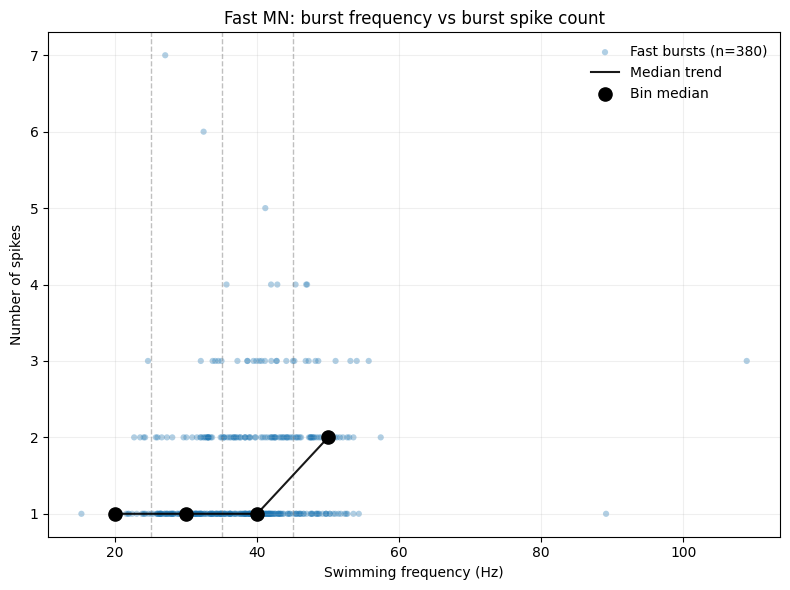

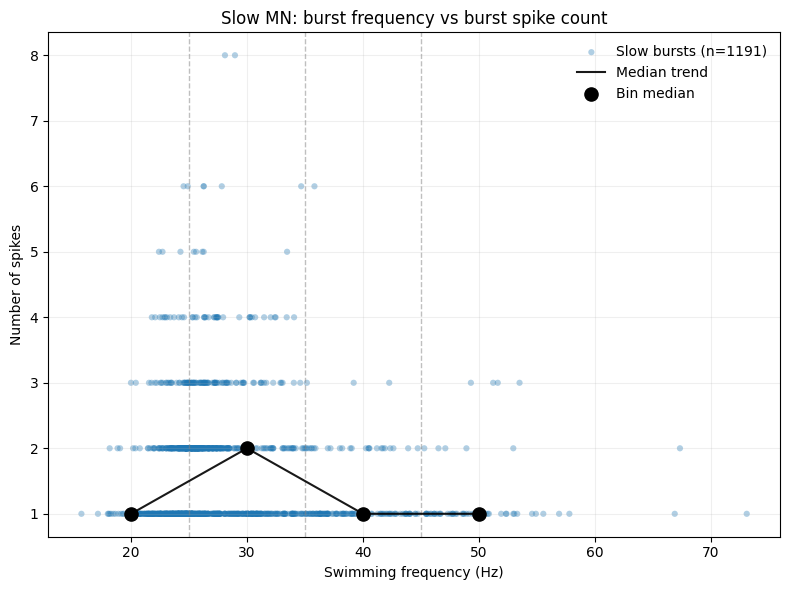

In [79]:
# Plot: one figure for all fast bursts, one for all slow bursts (median version)

def plot_speed_group_scatter(df_points, df_bin_means, speed_group):
    sub = df_points[df_points["speed_group"] == speed_group].copy()
    sub_bins = df_bin_means[df_bin_means["speed_group"] == speed_group].copy()

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(
        sub["burst_frequency_hz"],
        sub["burst_spike_count"],
        s=20,
        alpha=0.35,
        color="tab:blue",
        edgecolors="none",
        label=f"{speed_group.title()} bursts (n={len(sub)})"
    )

    if not sub_bins.empty:
        sub_bins = sub_bins.sort_values("bin_center_hz")
        median_by_bin = (
            sub
            .dropna(subset=["freq_bin", "burst_spike_count"])
            .groupby("freq_bin", observed=True, as_index=False)
            .agg(median_spike_count=("burst_spike_count", "median"))
        )
        sub_stats = sub_bins[["freq_bin", "bin_center_hz", "std_spike_count"]].merge(
            median_by_bin, on="freq_bin", how="left"
        ).sort_values("bin_center_hz")

        ax.plot(
            sub_stats["bin_center_hz"],
            sub_stats["median_spike_count"],
            color="black",
            linewidth=1.5,
            alpha=0.9,
            zorder=4,
            label="Median trend"
        )
        ax.scatter(
            sub_stats["bin_center_hz"],
            sub_stats["median_spike_count"],
            s=90,
            color="black",
            zorder=5,
            label="Bin median"
        )
        # ax.errorbar(
        #     sub_stats["bin_center_hz"],
        #     sub_stats["median_spike_count"],
        #     yerr=sub_stats["std_spike_count"],
        #     fmt="none",
        #     ecolor="black",
        #     elinewidth=1.5,
        #     capsize=4,
        #     zorder=6,
        #     label="Median ± SD"
        # )

    for x in [25, 35, 45]:
        ax.axvline(x, color="gray", linestyle="--", linewidth=1, alpha=0.5)

    ax.set_title(f"{speed_group.title()} MN: burst frequency vs burst spike count")
    ax.set_xlabel("Swimming frequency (Hz)")
    ax.set_ylabel("Number of spikes")
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

plot_speed_group_scatter(burst_points, bin_means, "fast")
plot_speed_group_scatter(burst_points, bin_means, "slow")

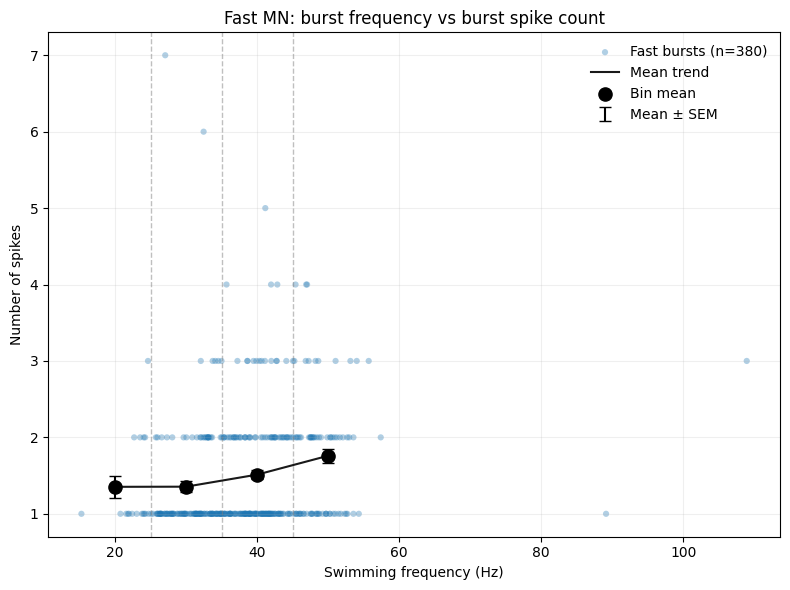

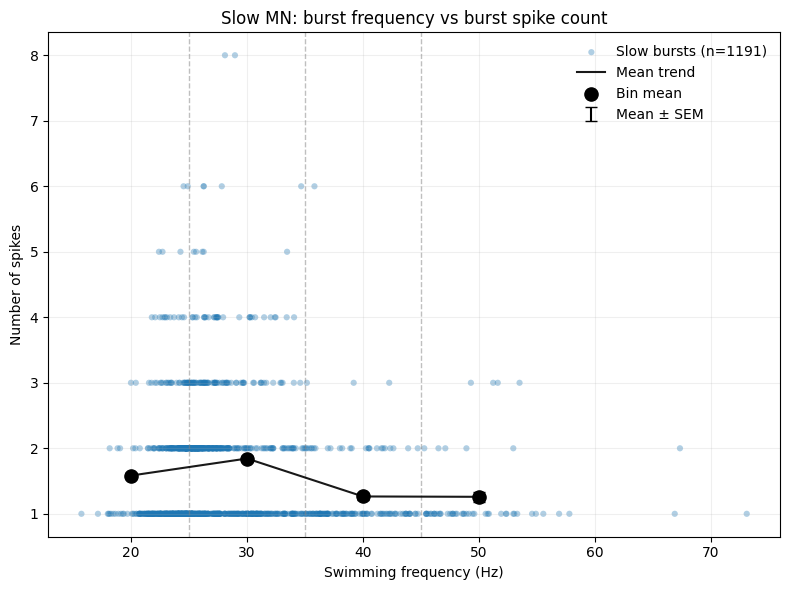

In [80]:
# Plot: one figure for all fast bursts, one for all slow bursts

def plot_speed_group_scatter(df_points, df_bin_means, speed_group):
    sub = df_points[df_points["speed_group"] == speed_group].copy()
    sub_bins = df_bin_means[df_bin_means["speed_group"] == speed_group].copy()

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(
        sub["burst_frequency_hz"],
        sub["burst_spike_count"],
        s=20,
        alpha=0.35,
        color="tab:blue",
        edgecolors="none",
        label=f"{speed_group.title()} bursts (n={len(sub)})"
    )

    if not sub_bins.empty:
        sub_bins = sub_bins.sort_values("bin_center_hz")
        ax.plot(
            sub_bins["bin_center_hz"],
            sub_bins["mean_spike_count"],
            color="black",
            linewidth=1.5,
            alpha=0.9,
            zorder=4,
            label="Mean trend"
        )
        ax.scatter(
            sub_bins["bin_center_hz"],
            sub_bins["mean_spike_count"],
            s=90,
            color="black",
            zorder=5,
            label="Bin mean"
        )
        ax.errorbar(
            sub_bins["bin_center_hz"],
            sub_bins["mean_spike_count"],
            yerr=sub_bins["sem_spike_count"],
            fmt="none",
            ecolor="black",
            elinewidth=1.5,
            capsize=4,
            zorder=6,
            label="Mean ± SEM"
        )

    for x in [25, 35, 45]:
        ax.axvline(x, color="gray", linestyle="--", linewidth=1, alpha=0.5)

    ax.set_title(f"{speed_group.title()} MN: burst frequency vs burst spike count")
    ax.set_xlabel("Swimming frequency (Hz)")
    ax.set_ylabel("Number of spikes")
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

plot_speed_group_scatter(burst_points, bin_means, "fast")
plot_speed_group_scatter(burst_points, bin_means, "slow")

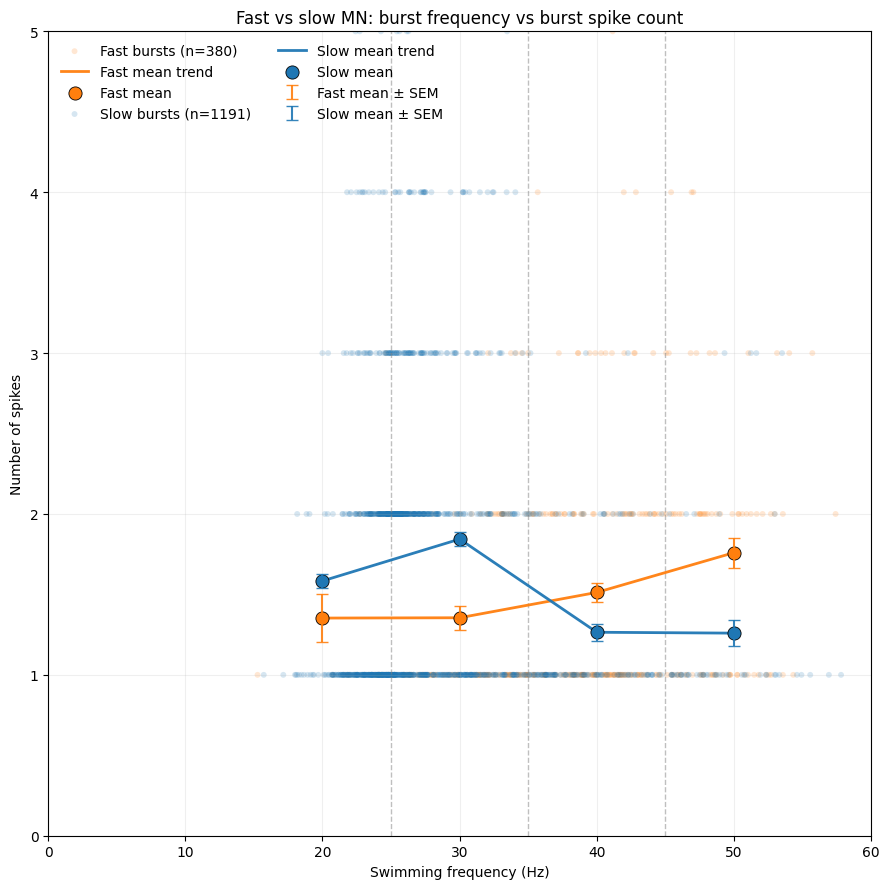

In [81]:
# Combined plot: fast and slow bursts on the same graph with mean markers
def plot_combined_speed_groups(df_points, df_bin_means):
    fig, ax = plt.subplots(figsize=(9, 9))

    colors = {
        "fast": "tab:orange",
        "slow": "tab:blue",
    }

    for speed_group in ["fast", "slow"]:
        sub = df_points[df_points["speed_group"] == speed_group].copy()
        sub_bins = df_bin_means[df_bin_means["speed_group"] == speed_group].copy()

        if sub.empty:
            continue

        color = colors[speed_group]

        ax.scatter(
            sub["burst_frequency_hz"],
            sub["burst_spike_count"],
            s=18,
            alpha=0.18,
            color=color,
            edgecolors="none",
            label=f"{speed_group.title()} bursts (n={len(sub)})"
        )

        if not sub_bins.empty:
            sub_bins = sub_bins.sort_values("bin_center_hz")
            ax.plot(
                sub_bins["bin_center_hz"],
                sub_bins["mean_spike_count"],
                color=color,
                linewidth=2,
                alpha=0.95,
                zorder=4,
                label=f"{speed_group.title()} mean trend"
            )
            ax.scatter(
                sub_bins["bin_center_hz"],
                sub_bins["mean_spike_count"],
                s=90,
                color=color,
                edgecolors="black",
                linewidth=0.6,
                zorder=5,
                label=f"{speed_group.title()} mean"
            )
            ax.errorbar(
                sub_bins["bin_center_hz"],
                sub_bins["mean_spike_count"],
                yerr=sub_bins["sem_spike_count"],
                fmt="none",
                ecolor=color,
                elinewidth=1.5,
                capsize=4,
                alpha=0.9,
                zorder=6,
                label=f"{speed_group.title()} mean ± SEM"
            )

    for x in [25, 35, 45]:
        ax.axvline(x, color="gray", linestyle="--", linewidth=1, alpha=0.5)

    ax.set_title("Fast vs slow MN: burst frequency vs burst spike count")
    ax.set_xlabel("Swimming frequency (Hz)")
    ax.set_ylabel("Number of spikes")
    ax.set_xlim(0, 60)
    ax.set_ylim(0, 5)

    ax.grid(alpha=0.2)
    ax.legend(frameon=False, ncol=2)
    plt.tight_layout()
    plt.show()

plot_combined_speed_groups(burst_points, bin_means)

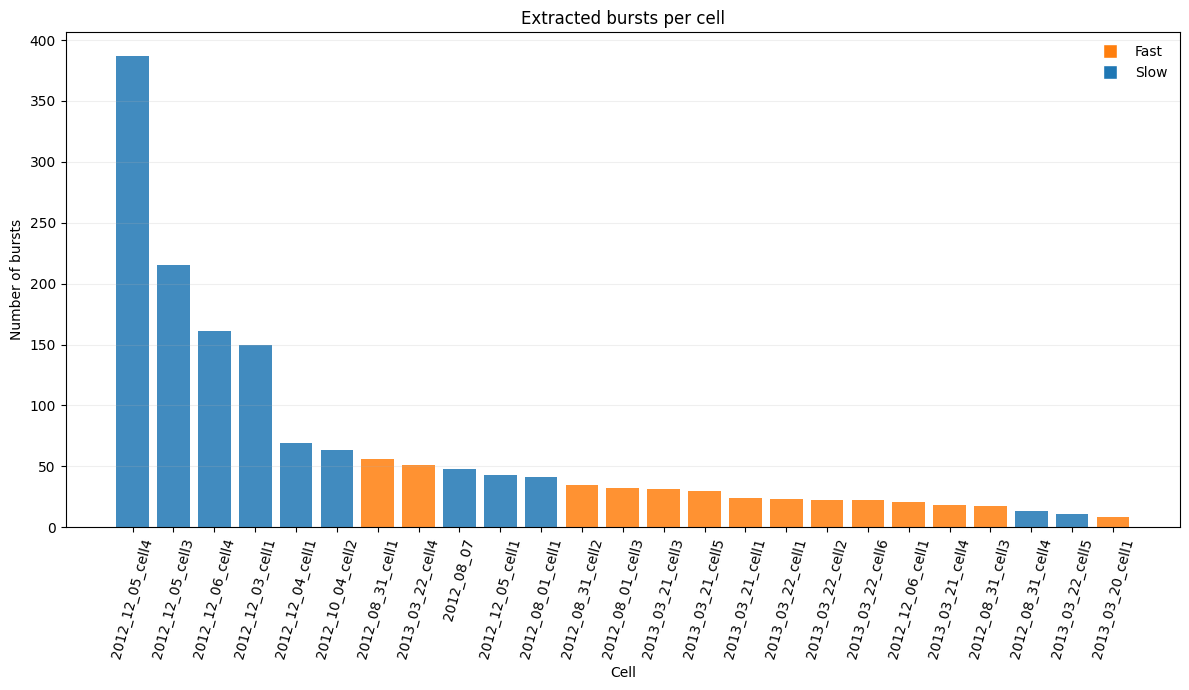

In [53]:
# Visualization: bursts per cell, colored by fast/slow
if "bursts_per_cell" not in globals():
    raise NameError("Run the bursts-per-cell summary cell above first to create `bursts_per_cell`.")

plot_df = bursts_per_cell.sort_values(["n_bursts", "cell"], ascending=[False, True]).copy()
colors = plot_df["speed_group"].map({"fast": "tab:orange", "slow": "tab:blue"}).fillna("gray")

fig, ax = plt.subplots(figsize=(12, 7))
ax.bar(plot_df["cell"], plot_df["n_bursts"], color=colors, alpha=0.85)

ax.set_title("Extracted bursts per cell")
ax.set_xlabel("Cell")
ax.set_ylabel("Number of bursts")
ax.tick_params(axis="x", rotation=75)
ax.grid(axis="y", alpha=0.2)

legend_handles = [
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="tab:orange", markersize=10, label="Fast"),
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="tab:blue", markersize=10, label="Slow"),
]
ax.legend(handles=legend_handles, frameon=False)

plt.tight_layout()
plt.show()

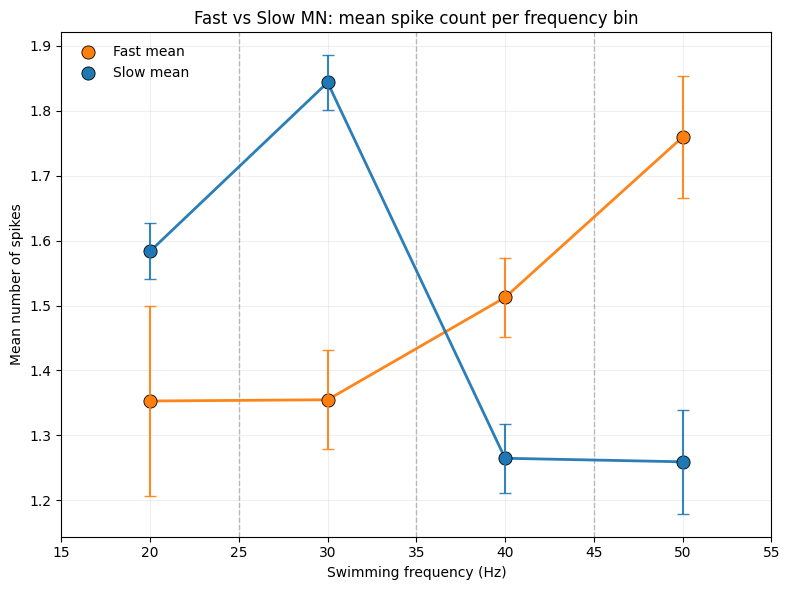

In [85]:

# Plot: mean values only (no individual burst scatter), fast vs slow trend lines
def plot_means_only(df_bin_means):
    fig, ax = plt.subplots(figsize=(8, 6))

    colors = {"fast": "tab:orange", "slow": "tab:blue"}

    for speed_group in ["fast", "slow"]:
        sub_bins = df_bin_means[df_bin_means["speed_group"] == speed_group].copy()
        if sub_bins.empty:
            continue

        sub_bins = sub_bins.sort_values("bin_center_hz")
        color = colors[speed_group]

        ax.plot(
            sub_bins["bin_center_hz"],
            sub_bins["mean_spike_count"],
            color=color,
            linewidth=2,
            alpha=0.95,
            zorder=4,
        )
        ax.scatter(
            sub_bins["bin_center_hz"],
            sub_bins["mean_spike_count"],
            s=90,
            color=color,
            edgecolors="black",
            linewidth=0.6,
            zorder=5,
            label=f"{speed_group.title()} mean"
        )
        ax.errorbar(
            sub_bins["bin_center_hz"],
            sub_bins["mean_spike_count"],
            yerr=sub_bins["sem_spike_count"],
            fmt="none",
            ecolor=color,
            elinewidth=1.5,
            capsize=4,
            alpha=0.9,
            zorder=6,
        )

    for x in [25, 35, 45]:
        ax.axvline(x, color="gray", linestyle="--", linewidth=1, alpha=0.5)

    ax.set_title("Fast vs Slow MN: mean spike count per frequency bin")
    ax.set_xlabel("Swimming frequency (Hz)")
    ax.set_ylabel("Mean number of spikes")
    ax.set_xlim(15, 55)
    # ax.set_ylim(20, 50)

    ax.grid(alpha=0.2)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

plot_means_only(bin_means)
